<a href="https://colab.research.google.com/github/SakaSaheed/AI-ML-Project/blob/main/Prof_Igboama_VES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Prof. Igboama campus VES code

"""
Complete Machine Learning Pipeline for VES Soil Type Detection
Using Random Forest Classifier

"""

Deepseek link: https://chat.deepseek.com/a/chat/s/a932a394-d824-4c1c-bb12-ab0f3e7da7b0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_recall_fscore_support, roc_curve, auc,
                             ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [3]:
print("="*60)
print("STEP 1: Loading and Preparing VES Data")
print("="*60)

STEP 1: Loading and Preparing VES Data


In [4]:
#Import data from google drive
import requests
import pandas as pd
from io import StringIO

def read_gd(sharingurl):
    file_id = sharingurl.split('/')[-2]
    # Changed to direct CSV export link for Google Sheets
    download_url = 'https://docs.google.com/spreadsheets/d/' + file_id + '/export?format=csv'
    url_content = requests.get(download_url).text
    return url_content # Return raw text

url = "https://docs.google.com/spreadsheets/d/1yIaw8dwE5X-nUvy6Gj3g6mNYfeXgdrS2/edit?usp=sharing&ouid=108326706958622812746&rtpof=true&sd=true"
data_raw_string = read_gd(url)

# Display the first few lines of the raw CSV content to confirm it's comma-separated
print("First 5 lines of the raw CSV content:")
for line in data_raw_string.splitlines()[:5]:
    print(line)

# Now, read the CSV content into a DataFrame
df_raw = pd.read_csv(StringIO(data_raw_string))

print("DataFrame Columns:", df_raw.columns.tolist())

df_raw.head()

First 5 lines of the raw CSV content:
VES,Resistivity,Thickness,Depth,Curve Type,Lithology
1,262,0.523,0.523,A,Topsoil
,318,0.829,1.35,,Upper saprolite
,344,,,,Lower saprolite
2,61.8,0.333,0.333,A,Topsoil
DataFrame Columns: ['VES', 'Resistivity', 'Thickness', 'Depth', 'Curve Type', 'Lithology']


,VES,Resistivity,Thickness,Depth,Curve Type,Lithology
0,1.0,262.0,0.523,0.523,A,Topsoil
1,NaN,318.0,0.829,1.350,NaN,Upper saprolite
2,NaN,344.0,NaN,NaN,NaN,Lower saprolite
3,2.0,61.8,0.333,0.333,A,Topsoil
4,NaN,108.0,1.370,1.700,NaN,Upper saprolite


In [5]:
print(f"Raw data shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")

Raw data shape: (109, 6)
Columns: ['VES', 'Resistivity', 'Thickness', 'Depth', 'Curve Type', 'Lithology']


In [6]:
# Rename columns for easier access
df_raw.columns = ['VES', 'Resistivity', 'Thickness', 'Depth', 'Curve_Type', 'Lithology']

# Remove rows where all key columns are NaN (empty rows)
df_clean = df_raw.dropna(subset=['Resistivity', 'Lithology'], how='all')
df_clean = df_clean.fillna(method='ffill', limit=1)  # Forward fill VES numbers

print(f"Clean data shape: {df_clean.shape}")

Clean data shape: (109, 6)


In [7]:
# ============================================
# STEP 2: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================
print("\n" + "="*60)
print("STEP 2: Exploratory Data Analysis")
print("="*60)

# Display basic info
print("\nDataset Info:")
print(df_clean.info())

print("\nMissing Values:")
print(df_clean.isnull().sum())

print("\nLithology Distribution:")
lithology_counts = df_clean['Lithology'].value_counts()
print(lithology_counts)


STEP 2: Exploratory Data Analysis

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   VES          60 non-null     float64
 1   Resistivity  109 non-null    float64
 2   Thickness    109 non-null    float64
 3   Depth        109 non-null    float64
 4   Curve_Type   60 non-null     object 
 5   Lithology    109 non-null    object 
dtypes: float64(4), object(2)
memory usage: 5.2+ KB
None

Missing Values:
VES            49
Resistivity     0
Thickness       0
Depth           0
Curve_Type     49
Lithology       0
dtype: int64

Lithology Distribution:
Lithology
Topsoil                              30
Upper saprolite                      30
Lower saprolite                      24
Saprock                              13
Lower saprolite (Lateritic)           5
Lower saprolite (Weathered Layer)     3
Lower saprolite (Weathered layer)     2


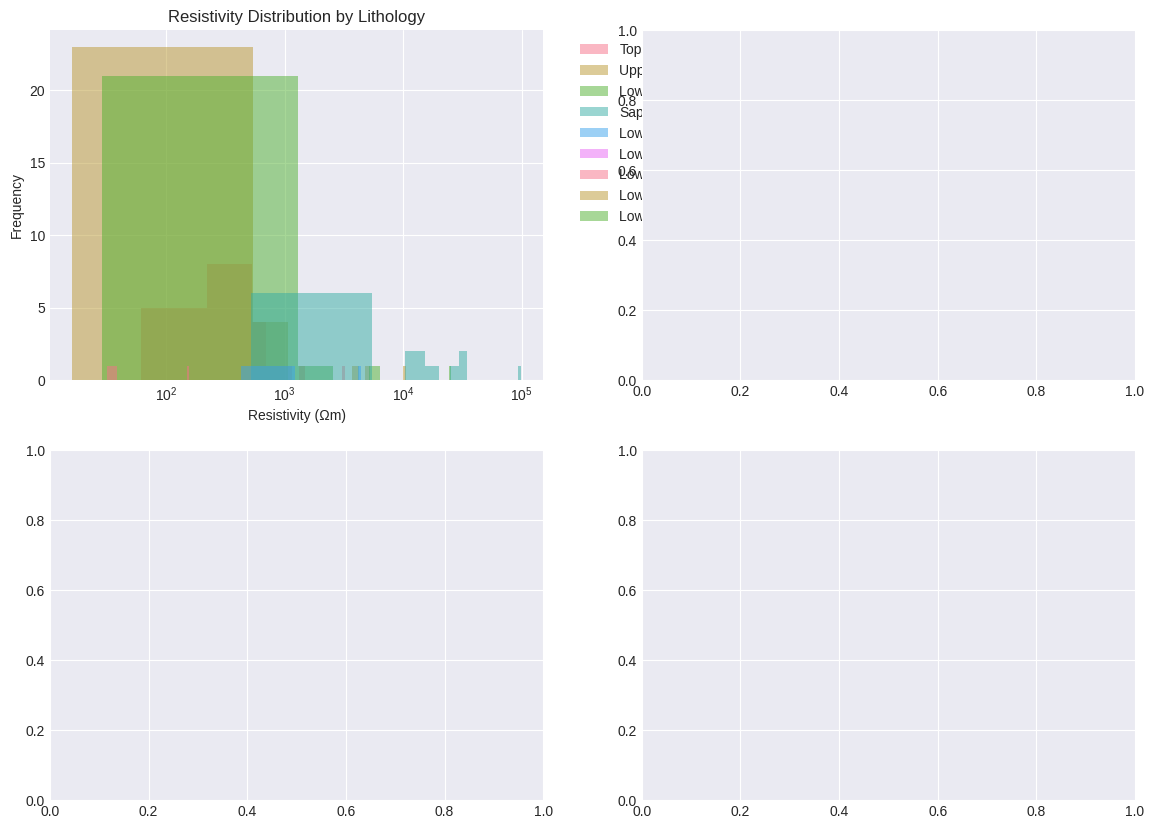

In [8]:
# Visualizations for EDA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Resistivity distribution by lithology
ax1 = axes[0, 0]
for lithology in df_clean['Lithology'].unique():
    subset = df_clean[df_clean['Lithology'] == lithology]['Resistivity'].dropna()
    if len(subset) > 0:
        ax1.hist(subset, alpha=0.5, label=lithology, bins=20)
ax1.set_xlabel('Resistivity (Ωm)')
ax1.set_ylabel('Frequency')
ax1.set_title('Resistivity Distribution by Lithology')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.set_xscale('log')


In [9]:

# 2. Box plot of resistivity by lithology
ax2 = axes[0, 1]
df_box = df_clean[['Lithology', 'Resistivity']].dropna()
df_box.boxplot(column='Resistivity', by='Lithology', ax=ax2, rot=45)
ax2.set_yscale('log')
ax2.set_title('Resistivity Box Plot by Lithology')
ax2.set_xlabel('Lithology')
ax2.set_ylabel('Resistivity (Ωm, log scale)')

# 3. Curve type distribution
ax3 = axes[1, 0]
df_clean['Curve_Type'].value_counts().plot(kind='bar', ax=ax3)
ax3.set_title('Curve Type Distribution')
ax3.set_xlabel('Curve Type')
ax3.set_ylabel('Count')
ax3.tick_params(axis='x', rotation=45)

# 4. Depth vs Resistivity scatter
ax4 = axes[1, 1]
scatter = ax4.scatter(df_clean['Depth'], df_clean['Resistivity'],
                      c=pd.Categorical(df_clean['Lithology']).codes,
                      alpha=0.6, cmap='viridis')
ax4.set_xlabel('Depth (m)')
ax4.set_ylabel('Resistivity (Ωm)')
ax4.set_title('Depth vs Resistivity (colored by Lithology)')
ax4.set_yscale('log')
plt.colorbar(scatter, ax=ax4, label='Lithology Code')

plt.tight_layout()
plt.savefig('1_eda_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()


<Figure size 640x480 with 0 Axes>

In [10]:

# ============================================
# STEP 3: FEATURE ENGINEERING
# ============================================
print("\n" + "="*60)
print("STEP 3: Feature Engineering")
print("="*60)

# Create a copy for feature engineering
df_model = df_clean.copy()

# Add log-transformed resistivity (often better for geophysical data)
df_model['Log_Resistivity'] = np.log1p(df_model['Resistivity'])

# Add resistivity ratios (compared to previous layer where possible)
df_model['Resistivity_Ratio'] = df_model.groupby('VES')['Resistivity'].pct_change()
df_model['Resistivity_Ratio'] = df_model['Resistivity_Ratio'].fillna(0)

# Add thickness ratio
df_model['Thickness_Ratio'] = df_model.groupby('VES')['Thickness'].pct_change()
df_model['Thickness_Ratio'] = df_model['Thickness_Ratio'].fillna(0)

#Add layer position (1st, 2nd, 3rd, etc. within each VES)
df_model['Layer_Position'] = df_model.groupby('VES').cumcount() + 1


STEP 3: Feature Engineering


In [11]:
# Add total depth to bottom of layer
df_model['Total_Depth'] = df_model.groupby('VES')['Depth'].transform('max')

# Add relative depth (normalized by total depth)
df_model['Relative_Depth'] = df_model['Depth'] / df_model['Total_Depth']

# Create interaction features
df_model['Resistivity_x_Depth'] = df_model['Resistivity'] * df_model['Depth']
df_model['LogR_x_Depth'] = df_model['Log_Resistivity'] * df_model['Depth']

print("New features created:")
new_features = ['Log_Resistivity', 'Resistivity_Ratio', 'Thickness_Ratio',
                'Layer_Position', 'Relative_Depth', 'Resistivity_x_Depth', 'LogR_x_Depth']
for feat in new_features:
    print(f"  - {feat}")

New features created:
  - Log_Resistivity
  - Resistivity_Ratio
  - Thickness_Ratio
  - Layer_Position
  - Relative_Depth
  - Resistivity_x_Depth
  - LogR_x_Depth


In [12]:

# ============================================
# STEP 4: HANDLE MISSING VALUES
# ============================================
print("\n" + "="*60)
print("STEP 4: Handling Missing Values")
print("="*60)

# Select features for modeling
feature_columns = ['Resistivity', 'Log_Resistivity', 'Depth', 'Layer_Position',
                   'Relative_Depth', 'Resistivity_Ratio', 'Thickness_Ratio',
                   'Resistivity_x_Depth', 'LogR_x_Depth']

# For categorical features, we'll use Curve Type
df_model['Curve_Type_Encoded'] = df_model['Curve_Type'].astype('category').cat.codes

# Add encoded curve type to features
feature_columns.append('Curve_Type_Encoded')

# Prepare feature matrix X and target y
X = df_model[feature_columns].copy()
y = df_model['Lithology'].copy()

# Remove rows with missing target
valid_idx = y.notna()
X = X[valid_idx]
y = y[valid_idx]

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Missing values in features:\n{X.isnull().sum()}")

# Impute missing values with median (for numerical features)
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print("\nAfter imputation - missing values:", X_imputed.isnull().sum().sum())


STEP 4: Handling Missing Values
Feature matrix shape: (109, 10)
Target shape: (109,)
Missing values in features:
Resistivity             0
Log_Resistivity         0
Depth                   0
Layer_Position         49
Relative_Depth         49
Resistivity_Ratio       0
Thickness_Ratio         0
Resistivity_x_Depth     0
LogR_x_Depth            0
Curve_Type_Encoded      0
dtype: int64

After imputation - missing values: 0


In [13]:
# ============================================
# STEP 5: ENCODE TARGET LABELS
# ============================================
print("\n" + "="*60)
print("STEP 5: Encoding Target Labels")
print("="*60)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"Classes: {label_encoder.classes_}")
print(f"Class distribution:\n{pd.Series(y_encoded).value_counts()}")



STEP 5: Encoding Target Labels
Classes: ['Lower saprolite' 'Lower saprolite (Lateritic)'
 'Lower saprolite (Weathered Layer)' 'Lower saprolite (Weathered layer)'
 'Lower saprolite (Weathered)' 'Lower saprolite (lateritic)' 'Saprock'
 'Topsoil' 'Upper saprolite']
Class distribution:
7    30
8    30
0    24
6    13
1     5
2     3
3     2
4     1
5     1
Name: count, dtype: int64


In [14]:
# ============================================
# STEP 6: NORMALIZATION/SCALING
# ============================================
print("\n" + "="*60)
print("STEP 6: Feature Normalization")
print("="*60)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
print(f"Scaled features shape: {X_scaled.shape}")
print(f"Feature means after scaling: {X_scaled.mean(axis=0).round(2)}")
print(f"Feature stds after scaling: {X_scaled.std(axis=0).round(2)}")


STEP 6: Feature Normalization
Scaled features shape: (109, 10)
Feature means after scaling: [ 0. -0.  0. -0.  0. -0.  0.  0. -0.  0.]
Feature stds after scaling: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [15]:
# ============================================
# STEP 7: TRAIN-TEST SPLIT
# ============================================
print("\n" + "="*60)
print("STEP 7: Train-Test Split")
print("="*60)

# Identify classes with only one sample
class_counts = pd.Series(y_encoded).value_counts()
single_sample_classes = class_counts[class_counts < 2].index

# Filter out samples belonging to single-sample classes
mask = ~pd.Series(y_encoded).isin(single_sample_classes)
X_filtered = X_scaled[mask]
y_filtered = y_encoded[mask]

print(f"Original number of samples: {len(y_encoded)}")
print(f"Classes with single samples removed: {len(single_sample_classes)}")
print(f"Number of samples after filtering: {len(y_filtered)}")

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Training class distribution:\n{pd.Series(y_train).value_counts()}")
print(f"Test class distribution:\n{pd.Series(y_test).value_counts()}")


STEP 7: Train-Test Split
Original number of samples: 109
Classes with single samples removed: 2
Number of samples after filtering: 107
Training set size: 85 samples
Test set size: 22 samples
Training class distribution:
8    24
7    24
0    19
6    10
1     4
2     2
3     2
Name: count, dtype: int64
Test class distribution:
8    6
7    6
0    5
6    3
1    1
2    1
Name: count, dtype: int64


In [16]:
# ============================================
# STEP 8: RANDOM FOREST MODEL WITH HYPERPARAMETER TUNING
# ============================================
print("\n" + "="*60)
print("STEP 8: Training Random Forest Model")
print("="*60)

# Initialize Random Forest with reasonable defaults for small dataset
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)
print("Model training completed!")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Feature Importances:")
print(feature_importance.head(10))


STEP 8: Training Random Forest Model
Model training completed!

Top 10 Feature Importances:
               feature  importance
0          Resistivity    0.145865
4       Relative_Depth    0.141541
8         LogR_x_Depth    0.129628
7  Resistivity_x_Depth    0.121124
1      Log_Resistivity    0.118354
3       Layer_Position    0.116875
9   Curve_Type_Encoded    0.110053
2                Depth    0.092970
6      Thickness_Ratio    0.012073
5    Resistivity_Ratio    0.011517


In [17]:
# ============================================
# STEP 9: CROSS-VALIDATION
# ============================================
print("\n" + "="*60)
print("STEP 9: Cross-Validation")
print("="*60)

# Perform 5-fold stratified cross-validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_scaled, y_encoded, cv=cv_strategy, scoring='accuracy')

print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

# Also compute other metrics via cross-validation
cv_precision = cross_val_score(rf_model, X_scaled, y_encoded, cv=cv_strategy, scoring='precision_macro')
cv_recall = cross_val_score(rf_model, X_scaled, y_encoded, cv=cv_strategy, scoring='recall_macro')
cv_f1 = cross_val_score(rf_model, X_scaled, y_encoded, cv=cv_strategy, scoring='f1_macro')

print(f"Mean CV Precision (macro): {cv_precision.mean():.3f}")
print(f"Mean CV Recall (macro): {cv_recall.mean():.3f}")
print(f"Mean CV F1-Score (macro): {cv_f1.mean():.3f}")


STEP 9: Cross-Validation
Cross-validation accuracy scores: [0.90909091 0.81818182 0.81818182 0.86363636 0.80952381]
Mean CV accuracy: 0.844 (+/- 0.076)
Mean CV Precision (macro): 0.658
Mean CV Recall (macro): 0.686
Mean CV F1-Score (macro): 0.648


In [18]:
# ============================================
# STEP 10: PREDICTIONS ON TEST SET
# ============================================
print("\n" + "="*60)
print("STEP 10: Test Set Predictions")
print("="*60)

y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test set accuracy: {test_accuracy:.3f}")

# Classification report
print("\nClassification Report:")
# Get the class names that are actually present in the test set
test_class_indices = np.unique(y_test)
test_target_names = label_encoder.inverse_transform(test_class_indices)
print(classification_report(y_test, y_pred, labels=test_class_indices, target_names=test_target_names))


STEP 10: Test Set Predictions
Test set accuracy: 0.955

Classification Report:
                                   precision    recall  f1-score   support

                  Lower saprolite       1.00      0.80      0.89         5
      Lower saprolite (Lateritic)       1.00      1.00      1.00         1
Lower saprolite (Weathered Layer)       1.00      1.00      1.00         1
                          Saprock       0.75      1.00      0.86         3
                          Topsoil       1.00      1.00      1.00         6
                  Upper saprolite       1.00      1.00      1.00         6

                         accuracy                           0.95        22
                        macro avg       0.96      0.97      0.96        22
                     weighted avg       0.97      0.95      0.96        22




STEP 11: Visualizing Results


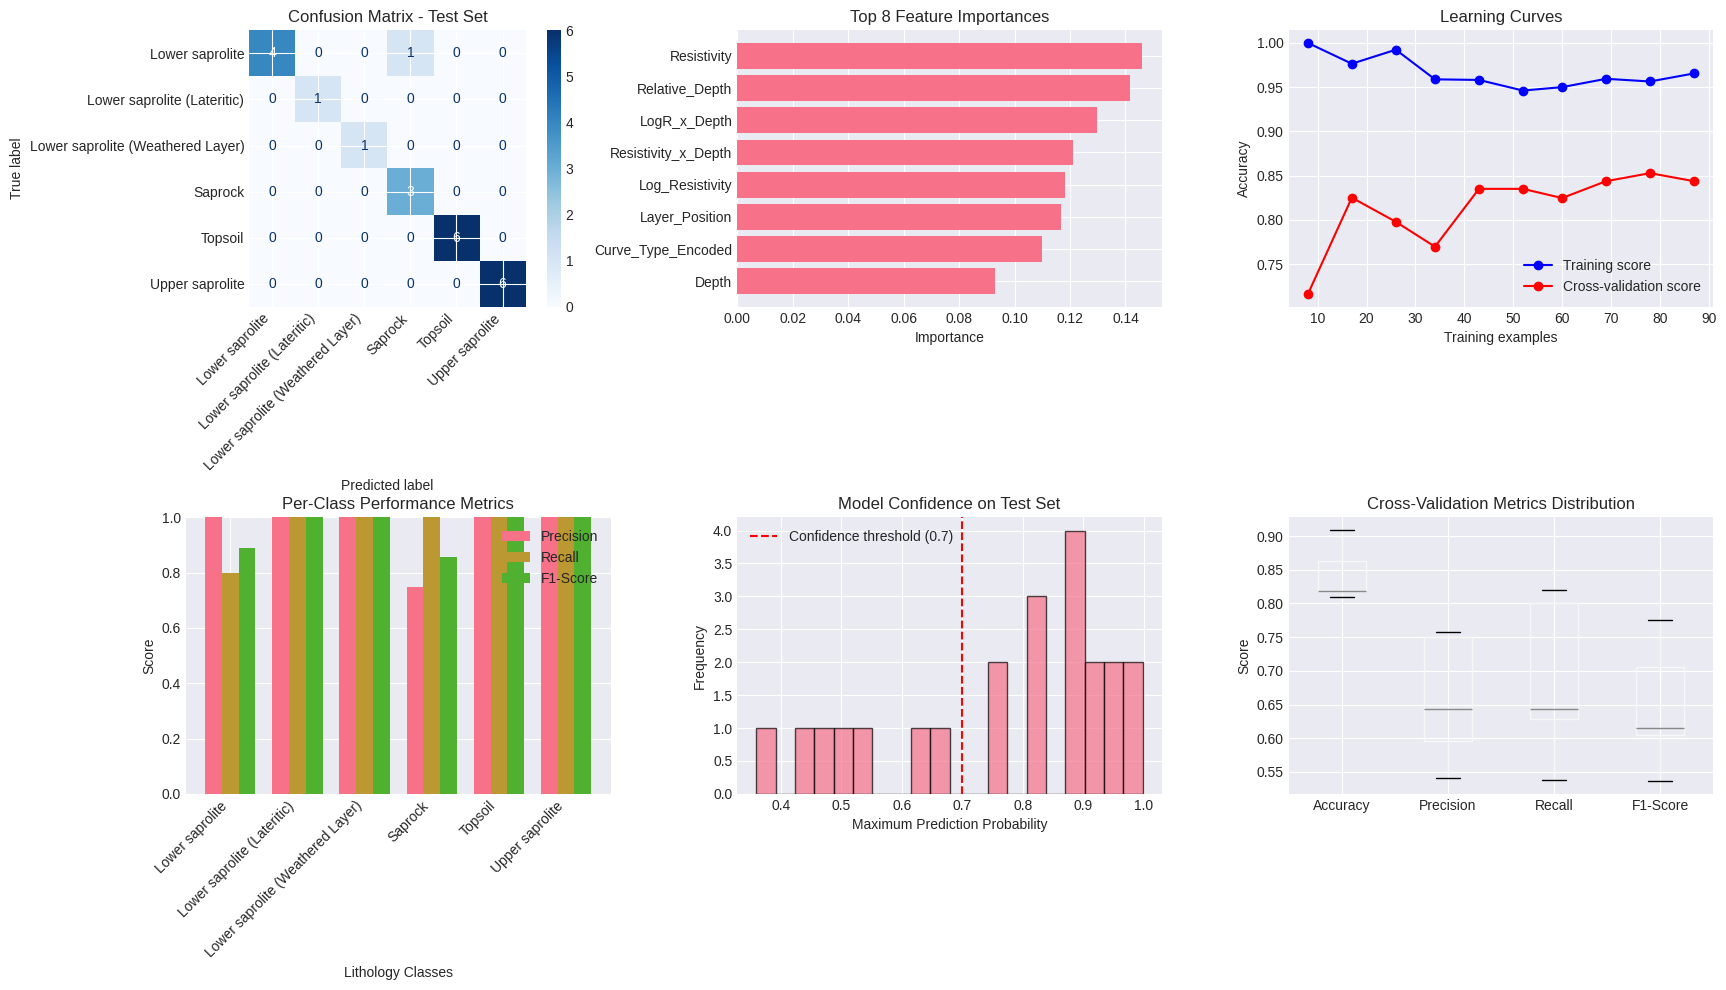

In [19]:
# ============================================
# STEP 11: VISUALIZATIONS FOR RESULTS
# ============================================
print("\n" + "="*60)
print("STEP 11: Visualizing Results")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Confusion Matrix
ax1 = axes[0, 0]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_target_names)
disp.plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title('Confusion Matrix - Test Set')
ax1.set_xticklabels(test_target_names, rotation=45, ha='right')

# 2. Feature Importance Bar Plot
ax2 = axes[0, 1]
top_features = feature_importance.head(8)
ax2.barh(top_features['feature'], top_features['importance'])
ax2.set_xlabel('Importance')
ax2.set_title('Top 8 Feature Importances')
ax2.invert_yaxis()

# 3. Training History (Learning Curves)
ax3 = axes[0, 2]
train_sizes, train_scores, test_scores = learning_curve(
    rf_model, X_scaled, y_encoded, cv=cv_strategy, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)
train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)
ax3.plot(train_sizes, train_scores_mean, 'o-', label='Training score', color='blue')
ax3.plot(train_sizes, test_scores_mean, 'o-', label='Cross-validation score', color='red')
ax3.set_xlabel('Training examples')
ax3.set_ylabel('Accuracy')
ax3.set_title('Learning Curves')
ax3.legend(loc='best')
ax3.grid(True)

# 4. Per-class metrics
ax4 = axes[1, 0]
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None, labels=test_class_indices)
classes = test_target_names # Corrected to use test_target_names
x = np.arange(len(classes))
width = 0.25
ax4.bar(x - width, precision, width, label='Precision')
ax4.bar(x, recall, width, label='Recall')
ax4.bar(x + width, f1, width, label='F1-Score')
ax4.set_xlabel('Lithology Classes')
ax4.set_ylabel('Score')
ax4.set_title('Per-Class Performance Metrics')
ax4.set_xticks(x)
ax4.set_xticklabels(classes, rotation=45, ha='right')
ax4.legend()
ax4.set_ylim([0, 1])

# 5. Prediction confidence distribution
ax5 = axes[1, 1]
max_probs = np.max(y_pred_proba, axis=1)
ax5.hist(max_probs, bins=20, edgecolor='black', alpha=0.7)
ax5.set_xlabel('Maximum Prediction Probability')
ax5.set_ylabel('Frequency')
ax5.set_title('Model Confidence on Test Set')
ax5.axvline(x=0.7, color='red', linestyle='--', label='Confidence threshold (0.7)')
ax5.legend()

# 6. Cross-validation box plot
ax6 = axes[1, 2]
cv_metrics = pd.DataFrame({
    'Accuracy': cv_scores,
    'Precision': cv_precision,
    'Recall': cv_recall,
    'F1-Score': cv_f1
})
cv_metrics.boxplot(ax=ax6)
ax6.set_ylabel('Score')
ax6.set_title('Cross-Validation Metrics Distribution')
ax6.grid(True)

plt.tight_layout()
plt.savefig('2_model_results.png', dpi=300, bbox_inches='tight')
plt.show()


STEP 12: ROC Curves (One-vs-Rest)


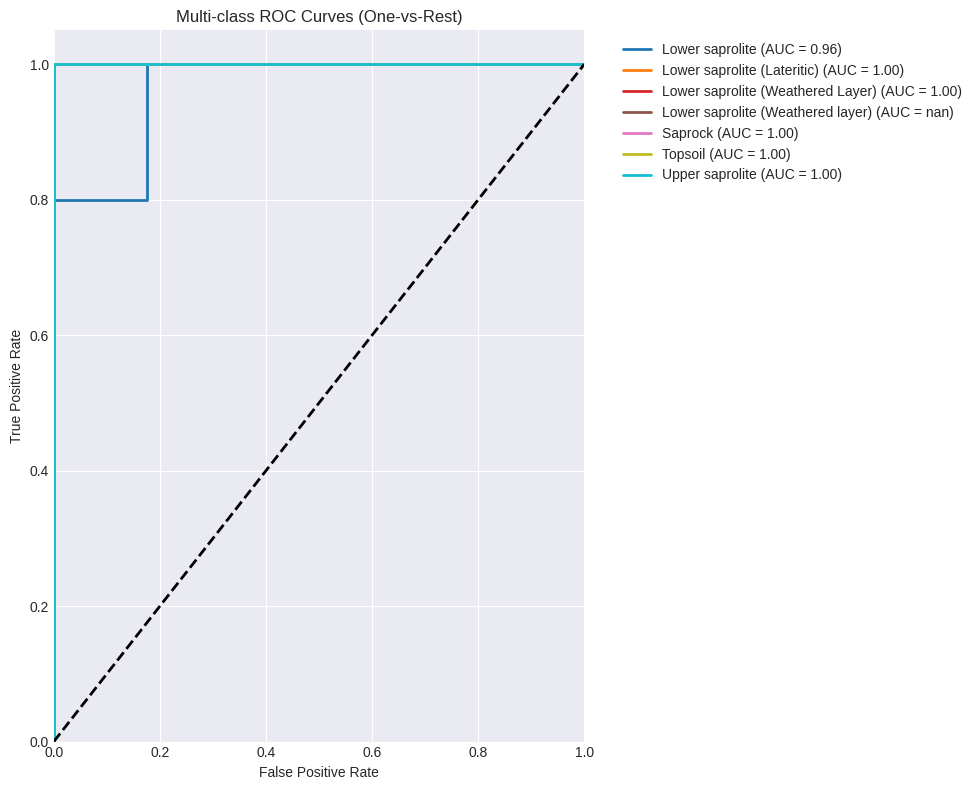

In [20]:

# ============================================
# STEP 12: ROC CURVES (for multi-class)
# ============================================
print("\n" + "="*60)
print("STEP 12: ROC Curves (One-vs-Rest)")
print("="*60)

from sklearn.preprocessing import label_binarize

# Get the unique classes that the model was trained on and predicts
unique_model_classes = np.unique(y_filtered)
n_classes_model = len(unique_model_classes)

# Binarize the output for ROC curves, using only the classes the model considers
y_test_bin = label_binarize(y_test, classes=unique_model_classes)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes_model):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, n_classes_model))

for i, color in zip(range(n_classes_model), colors):
    # Get the actual lithology name for the current class index
    class_label = label_encoder.inverse_transform([unique_model_classes[i]])[0]
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_label} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curves (One-vs-Rest)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.savefig('3_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()


In [21]:
# ============================================
# STEP 13: SAVE MODEL AND RESULTS
# ============================================
print("\n" + "="*60)
print("STEP 13: Saving Model and Results")
print("="*60)

import joblib
import json
from datetime import datetime

# Save the model, scaler, and encoders
joblib.dump(rf_model, 'random_forest_soil_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')
joblib.dump(imputer, 'imputer.pkl')

# Save feature importance
feature_importance.to_csv('feature_importance.csv', index=False)

# Save results summary
results_summary = {
    'model': 'Random Forest Classifier',
    'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'cv_accuracy_mean': float(cv_scores.mean()),
    'cv_accuracy_std': float(cv_scores.std()),
    'test_accuracy': float(test_accuracy),
    'cv_precision_macro': float(cv_precision.mean()),
    'cv_recall_macro': float(cv_recall.mean()),
    'cv_f1_macro': float(cv_f1.mean()),
    'n_samples': int(len(X_scaled)),
    'n_features': int(X_scaled.shape[1]),
    'n_classes': int(n_classes_model), # Corrected from n_classes to n_classes_model
    'classes': label_encoder.classes_.tolist(),
    'feature_importance': feature_importance.to_dict('records')
}

with open('results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print("Model saved as 'random_forest_soil_model.pkl'")
print("Scaler saved as 'feature_scaler.pkl'")
print("Label encoder saved as 'label_encoder.pkl'")
print("Feature importance saved as 'feature_importance.csv'")
print("Results summary saved as 'results_summary.json'")


STEP 13: Saving Model and Results
Model saved as 'random_forest_soil_model.pkl'
Scaler saved as 'feature_scaler.pkl'
Label encoder saved as 'label_encoder.pkl'
Feature importance saved as 'feature_importance.csv'
Results summary saved as 'results_summary.json'


In [22]:
# ============================================
# STEP 14: PREDICTION FUNCTION FOR NEW DATA
# ============================================
print("\n" + "="*60)
print("STEP 14: Creating Prediction Function")
print("="*60)

def predict_soil_type(resistivity, depth, layer_position, curve_type, total_depth=None):
    """
    Predict soil type based on VES parameters

    Parameters:
    - resistivity: float, resistivity value (Ωm)
    - depth: float, depth to layer top (m)
    - layer_position: int, 1=Topsoil, 2=Upper saprolite, etc.
    - curve_type: str, curve type (A, H, K, Q, HA, HK, KH, HKH, QH)
    - total_depth: float, total depth of VES (if None, uses depth*2)

    Returns:
    - predicted_soil_type: str
    - probabilities: dict of class probabilities
    """
    # Load saved objects
    model = joblib.load('random_forest_soil_model.pkl')
    scaler = joblib.load('feature_scaler.pkl')
    encoder = joblib.load('label_encoder.pkl')
    imputer = joblib.load('imputer.pkl')

    # Calculate derived features
    log_resistivity = np.log1p(resistivity)

    if total_depth is None:
        total_depth = depth * 2  # rough estimate

    relative_depth = depth / total_depth if total_depth > 0 else 0
    resistivity_x_depth = resistivity * depth
    logr_x_depth = log_resistivity * depth

    # Encode curve type
    curve_types = ['A', 'H', 'K', 'Q', 'HA', 'HK', 'KH', 'HKH', 'QH']
    curve_encoded = curve_types.index(curve_type) if curve_type in curve_types else 0

    # Create feature array
    features = np.array([[
        resistivity, log_resistivity, depth, layer_position,
        relative_depth, 0, 0, resistivity_x_depth, logr_x_depth, curve_encoded
    ]])

    # Impute and scale
    features_imputed = imputer.transform(features)
    features_scaled = scaler.transform(features_imputed)

    # Predict
    prediction = model.predict(features_scaled)[0]
    probabilities = model.predict_proba(features_scaled)[0]

    # Get class names using model.classes_ for correct mapping
    soil_type = encoder.inverse_transform([prediction])[0]
    prob_dict = {encoder.inverse_transform([model.classes_[i]])[0]: probabilities[i] for i in range(len(model.classes_))}

    return soil_type, prob_dict

    # Test prediction function with example
print("\nExample prediction:")
example_soil, example_probs = predict_soil_type(
    resistivity=300,
    depth=1.5,
    layer_position=2,
    curve_type='A',
    total_depth=10
)
print(f"Predicted soil type: {example_soil}")
print(f"Probabilities: {example_probs}")


STEP 14: Creating Prediction Function

Example prediction:
Predicted soil type: Topsoil
Probabilities: {'Lower saprolite': np.float64(0.16070489844683394), 'Lower saprolite (Lateritic)': np.float64(0.0), 'Lower saprolite (Weathered Layer)': np.float64(0.0), 'Lower saprolite (Weathered layer)': np.float64(0.007037037037037037), 'Saprock': np.float64(0.0), 'Topsoil': np.float64(0.5246666666666667), 'Upper saprolite': np.float64(0.3075913978494624)}


In [23]:
# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "="*60)
print("MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY")
print("="*60)
print("\nSummary of Results:")
print(f"✓ Model: Random Forest Classifier")
print(f"✓ Cross-validation accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
print(f"✓ Test set accuracy: {test_accuracy:.3f}")
print(f"✓ Best features: {feature_importance.head(3)['feature'].tolist()}")
print("\nFiles generated:")
print("  1. 1_eda_visualizations.png - EDA plots")
print("  2. 2_model_results.png - Model performance plots")
print("  3. 3_roc_curves.png - ROC curves")
print("  4. random_forest_soil_model.pkl - Trained model")
print("  5. feature_scaler.pkl - StandardScaler object")
print("  6. label_encoder.pkl - Label encoder")
print("  7. imputer.pkl - Missing value imputer")
print("  8. feature_importance.csv - Feature importance table")
print("  9. results_summary.json - JSON results summary")
print("\n" + "="*60)


MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY

Summary of Results:
✓ Model: Random Forest Classifier
✓ Cross-validation accuracy: 0.844 (+/- 0.038)
✓ Test set accuracy: 0.955
✓ Best features: ['Resistivity', 'Relative_Depth', 'LogR_x_Depth']

Files generated:
  1. 1_eda_visualizations.png - EDA plots
  2. 2_model_results.png - Model performance plots
  3. 3_roc_curves.png - ROC curves
  4. random_forest_soil_model.pkl - Trained model
  5. feature_scaler.pkl - StandardScaler object
  6. label_encoder.pkl - Label encoder
  7. imputer.pkl - Missing value imputer
  8. feature_importance.csv - Feature importance table
  9. results_summary.json - JSON results summary



##Random Forest Vitualization

In [24]:
"""
Extended Visualizations for Random Forest Analysis
2D and 3D Plots for VES Soil Type Classification
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.inspection import DecisionBoundaryDisplay
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import seaborn as sns

# ============================================
# ADDITIONAL 2D AND 3D VISUALIZATIONS
# Add this code after your model training
# ============================================

print("\n" + "="*60)
print("CREATING 2D AND 3D VISUALIZATIONS")
print("="*60)

# Prepare data for visualizations
# Get the feature names and original scaled data
feature_names = feature_columns
X_viz = X_scaled
y_viz = y_encoded
y_labels = [label_encoder.classes_[i] for i in y_viz]


CREATING 2D AND 3D VISUALIZATIONS



1. Creating 3D PCA plot...


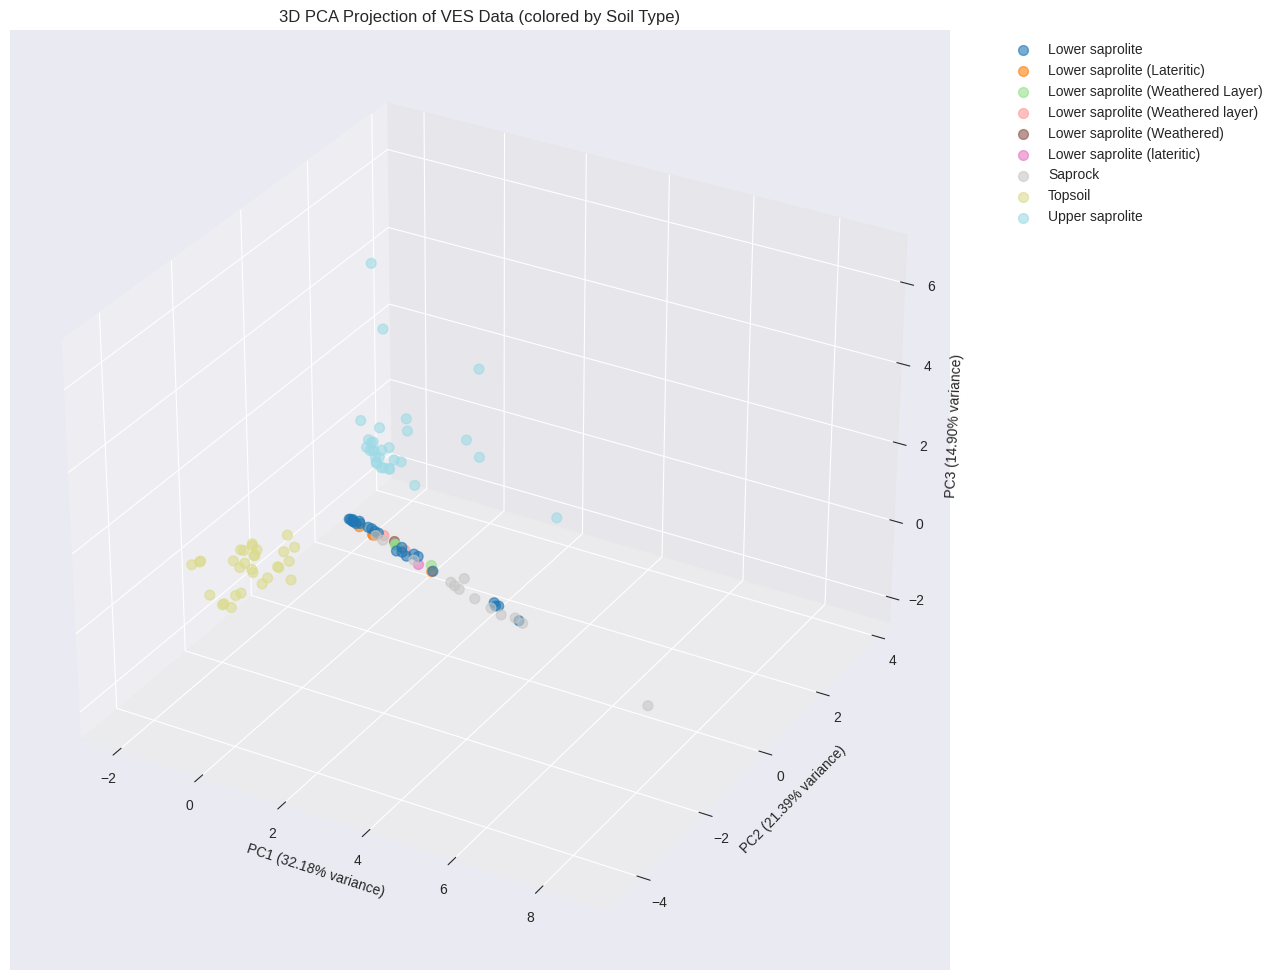

In [25]:
# ============================================
# 1. 3D PCA Visualization
# ============================================
print("\n1. Creating 3D PCA plot...")

# Apply PCA to reduce to 3 dimensions
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_viz)

# Create 3D scatter plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Get unique classes and assign colors
unique_classes = label_encoder.classes_
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_classes)))

for i, soil_type in enumerate(unique_classes):
    mask = y_viz == i
    ax.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
               c=[colors[i]], label=soil_type, s=50, alpha=0.6)

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.2%} variance)')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.2%} variance)')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.2%} variance)')
ax.set_title('3D PCA Projection of VES Data (colored by Soil Type)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('4_3d_pca_visualization.png', dpi=300, bbox_inches='tight')
plt.show()


In [26]:
# ============================================
# 2. Interactive 3D Plot with Plotly
# ============================================
print("\n2. Creating interactive 3D plot...")

# Create interactive 3D scatter plot
fig_interactive = px.scatter_3d(
    x=X_pca_3d[:, 0],
    y=X_pca_3d[:, 1],
    z=X_pca_3d[:, 2],
    color=[label_encoder.classes_[i] for i in y_viz],
    title='Interactive 3D PCA Visualization - VES Soil Types',
    labels={
        'x': f'PC1 ({pca_3d.explained_variance_ratio_[0]:.2%})',
        'y': f'PC2 ({pca_3d.explained_variance_ratio_[1]:.2%})',
        'z': f'PC3 ({pca_3d.explained_variance_ratio_[2]:.2%})'
    },
    opacity=0.7
)

# Add hover information with actual feature values
hover_texts = []
for i in range(len(X_viz)):
    hover_text = f"Soil Type: {label_encoder.classes_[y_viz[i]]}<br>"
    for j, feat in enumerate(feature_names[:5]):  # Show top 5 features
        hover_text += f"{feat}: {X_viz[i, j]:.2f}<br>"
    hover_texts.append(hover_text)

fig_interactive.update_traces(text=hover_texts, hovertemplate='%{text}<extra></extra>')
fig_interactive.write_html('5_interactive_3d_plot.html')
print("Interactive plot saved as '5_interactive_3d_plot.html'")


2. Creating interactive 3D plot...
Interactive plot saved as '5_interactive_3d_plot.html'



3. Creating decision boundary plots...


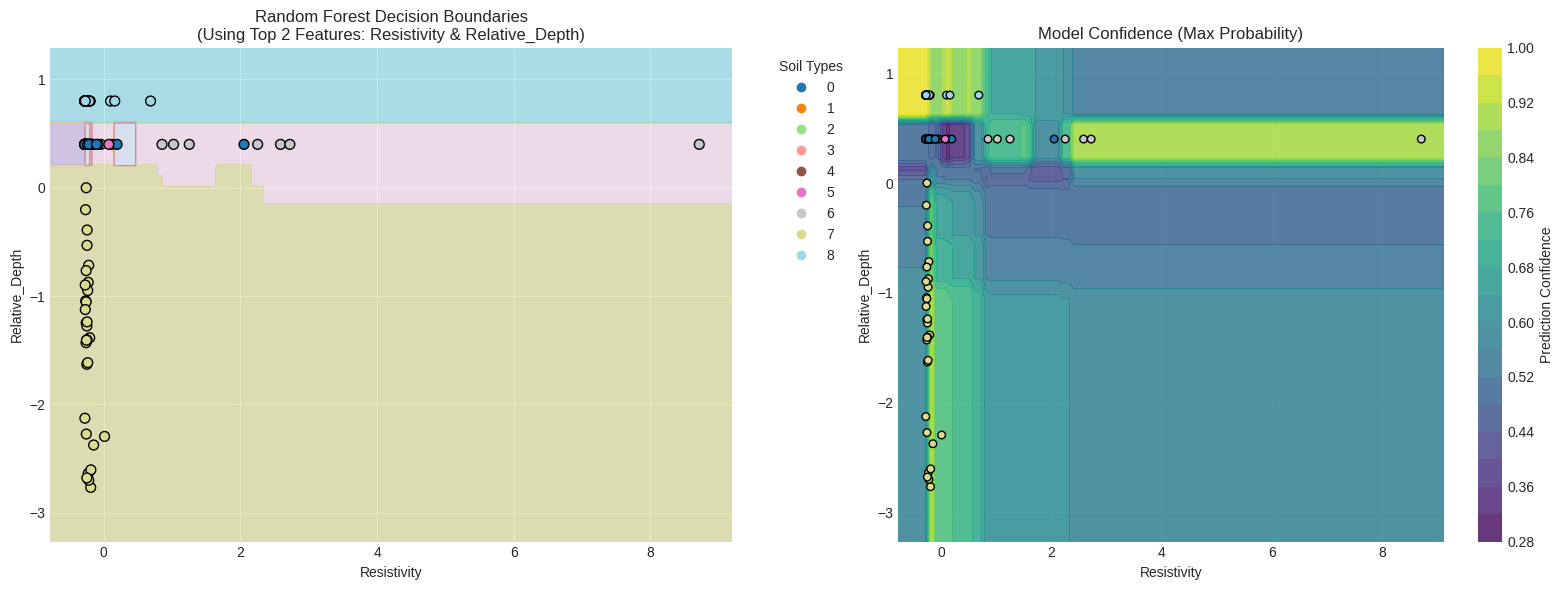

In [27]:

# ============================================
# 3. 2D Decision Boundary Plots (Top 2 Features)
# ============================================
print("\n3. Creating decision boundary plots...")

# Create mesh for top 2 most important features
top_2_features = feature_importance.head(2)['feature'].values
top_2_indices = [feature_names.index(f) for f in top_2_features]

# Train a simpler Random Forest for visualization (with limited depth)
rf_viz = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
rf_viz.fit(X_viz[:, top_2_indices], y_viz)

# Create mesh grid
x_min, x_max = X_viz[:, top_2_indices[0]].min() - 0.5, X_viz[:, top_2_indices[0]].max() + 0.5
y_min, y_max = X_viz[:, top_2_indices[1]].min() - 0.5, X_viz[:, top_2_indices[1]].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict on mesh
Z = rf_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundaries
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2D Decision Boundary Plot
ax1 = axes[0]
ax1.contourf(xx, yy, Z, alpha=0.3, cmap='tab20')
scatter = ax1.scatter(X_viz[:, top_2_indices[0]], X_viz[:, top_2_indices[1]],
                      c=y_viz, cmap='tab20', edgecolor='black', s=50)
ax1.set_xlabel(top_2_features[0])
ax1.set_ylabel(top_2_features[1])
ax1.set_title(f'Random Forest Decision Boundaries\n(Using Top 2 Features: {top_2_features[0]} & {top_2_features[1]})')
ax1.legend(*scatter.legend_elements(), title="Soil Types", bbox_to_anchor=(1.05, 1))

# 3D Surface Plot of Decision Function
ax2 = axes[1]
# Create mesh for 3D surface
xx_3d, yy_3d = np.meshgrid(np.arange(x_min, x_max, 0.1),
                            np.arange(y_min, y_max, 0.1))
Z_proba = rf_viz.predict_proba(np.c_[xx_3d.ravel(), yy_3d.ravel()])
Z_max_proba = Z_proba.max(axis=1).reshape(xx_3d.shape)

surf = ax2.contourf(xx_3d, yy_3d, Z_max_proba, levels=20, cmap='viridis', alpha=0.8)
ax2.scatter(X_viz[:, top_2_indices[0]], X_viz[:, top_2_indices[1]],
           c=y_viz, cmap='tab20', edgecolor='black', s=30)
ax2.set_xlabel(top_2_features[0])
ax2.set_ylabel(top_2_features[1])
ax2.set_title('Model Confidence (Max Probability)')
plt.colorbar(surf, ax=ax2, label='Prediction Confidence')

plt.tight_layout()
plt.savefig('6_decision_boundary_plots.png', dpi=300, bbox_inches='tight')
plt.show()


4. Creating 3D feature space with predictions...


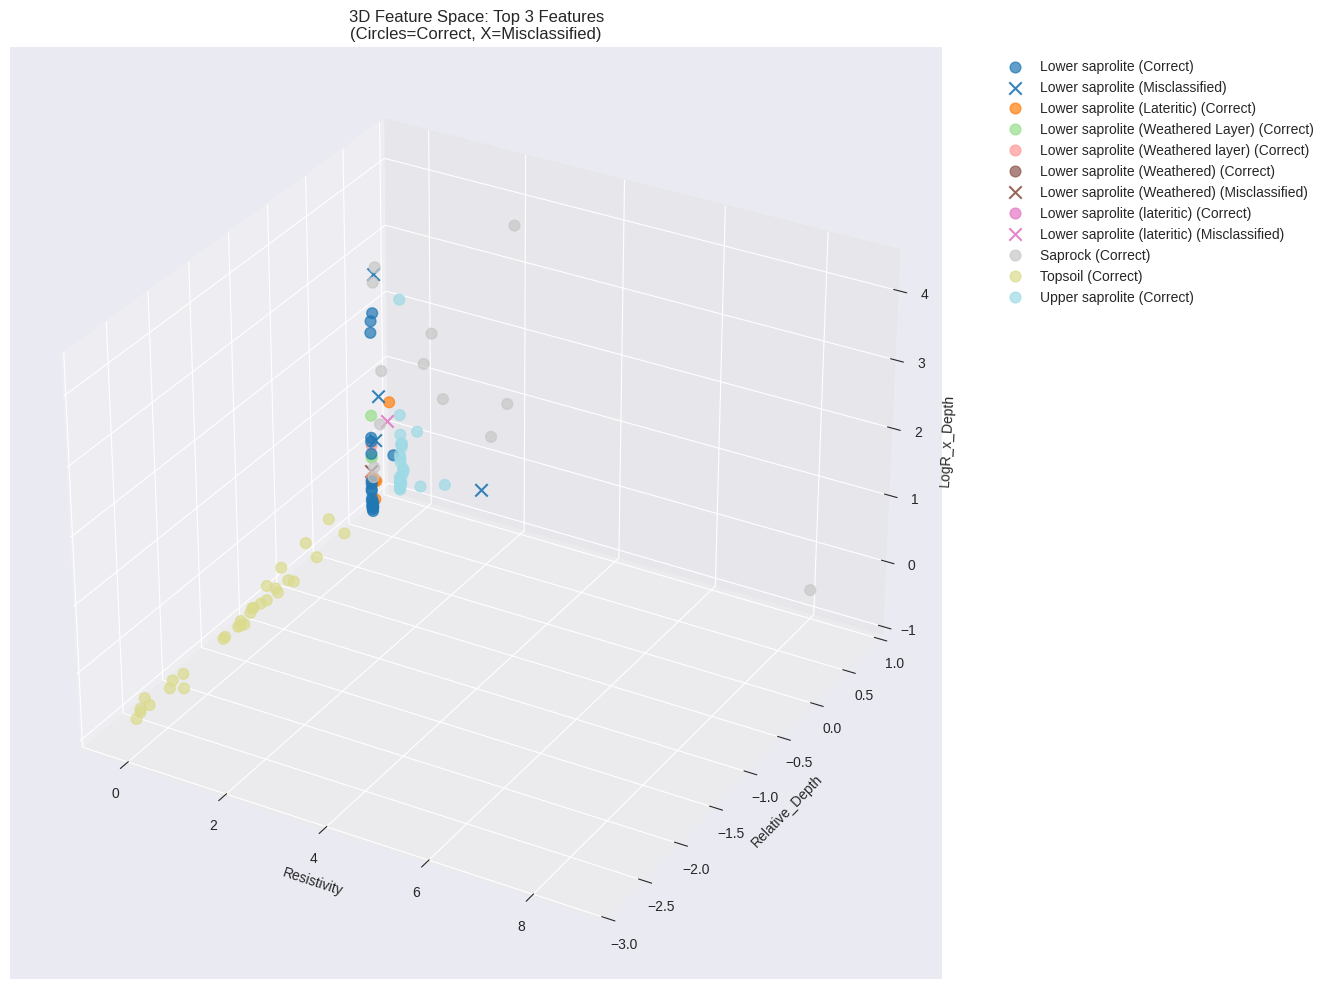

In [28]:
# ============================================
# 4. 3D Feature Space with Random Forest Predictions
# ============================================
print("\n4. Creating 3D feature space with predictions...")

# Select top 3 features for 3D visualization
top_3_features = feature_importance.head(3)['feature'].values
top_3_indices = [feature_names.index(f) for f in top_3_features]

# Create 3D scatter plot with predictions
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Get predictions
y_pred_full = rf_model.predict(X_viz)

# Create scatter plot with actual vs predicted
for i, soil_type in enumerate(unique_classes):
    mask_actual = y_viz == i
    mask_pred = y_pred_full == i

    # Plot correctly classified (solid markers)
    correct_mask = mask_actual & (y_pred_full == i)
    ax.scatter(X_viz[correct_mask, top_3_indices[0]],
               X_viz[correct_mask, top_3_indices[1]],
               X_viz[correct_mask, top_3_indices[2]],
               c=[colors[i]], marker='o', s=60, alpha=0.7,
               label=f'{soil_type} (Correct)')

    # Plot misclassified (x markers)
    wrong_mask = mask_actual & (y_pred_full != i)
    if wrong_mask.sum() > 0:
        ax.scatter(X_viz[wrong_mask, top_3_indices[0]],
                   X_viz[wrong_mask, top_3_indices[1]],
                   X_viz[wrong_mask, top_3_indices[2]],
                   c=[colors[i]], marker='x', s=80, alpha=0.9,
                   label=f'{soil_type} (Misclassified)')

ax.set_xlabel(top_3_features[0])
ax.set_ylabel(top_3_features[1])
ax.set_zlabel(top_3_features[2])
ax.set_title('3D Feature Space: Top 3 Features\n(Circles=Correct, X=Misclassified)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('7_3d_feature_space.png', dpi=300, bbox_inches='tight')
plt.show()

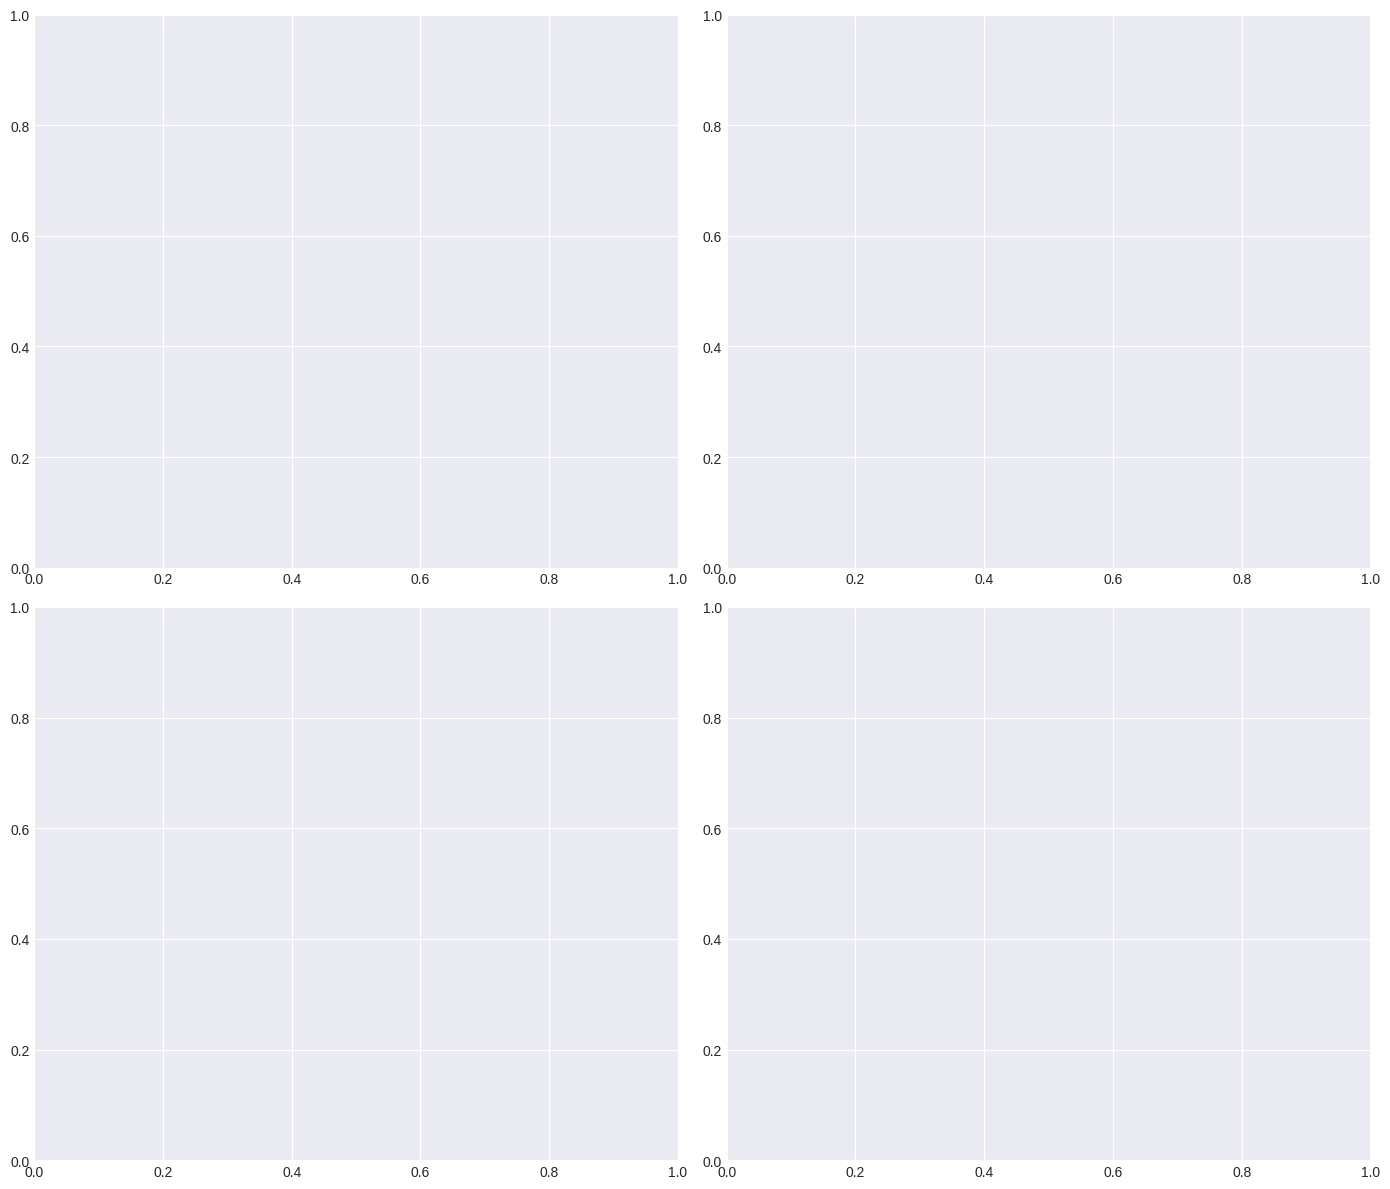

In [29]:
from sklearn.inspection import partial_dependence

# Create 2D partial dependence for top 2 feature pairs
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
feature_pairs = [(0, 1), (0, 2), (1, 2), (2, 3)]  # Use first 4 features

for idx, (feat1_idx, feat2_idx) in enumerate(feature_pairs[:4]):
    ax = axes[idx // 2, idx % 2]

    # Calculate partial dependence
    pdp = partial_dependence(
        rf_model, X_viz, [feat1_idx, feat2_idx], grid_resolution=20,
        kind='average'
    )

    # Plot 2D contour
    # Try accessing 'grid_points' first, as 'values' might be deprecated or causing issues
    pdp_values = pdp.get('grid_points') # Use .get() to safely retrieve, accounting for 'grid_points'
    if pdp_values is None:
        pdp_values = pdp.get('values') # Fallback to 'values' if 'grid_points' is not found

    if pdp_values is None:
        print(f"Warning: Could not retrieve feature values for Partial Dependence Plot for features: {feature_names[feat1_idx]}, {feature_names[feat2_idx]}. Skipping this plot.")
        continue # Skip this iteration if values are not available

    XX, YY = np.meshgrid(pdp_values[0], pdp_values[1])
    Z = pdp['average'][0].T

    contour = ax.contourf(XX, YY, Z, levels=20, cmap='RdYlBu_r', alpha=0.8)
    ax.set_xlabel(feature_names[feat1_idx])
    ax.set_ylabel(feature_names[feat2_idx])
    ax.set_title(f'Partial Dependence: {feature_names[feat1_idx]} vs {feature_names[feat2_idx]}')
    plt.colorbar(contour, ax=ax, label='Average Prediction')

plt.tight_layout()
plt.savefig('8_partial_dependence_2d.png', dpi=300, bbox_inches='tight')
plt.show()

##DECISION TREE CLASSIFIER FOR LITHOLOGY PREDICTION


In [30]:
"""
Decision Tree Classifier for VES Lithology Prediction
With Full Interpretation and Visualization
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             f1_score, precision_score, recall_score)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Assuming df_model is already prepared from previous code
# If not, run the data preparation code first

print("="*60)
print("DECISION TREE CLASSIFIER FOR LITHOLOGY PREDICTION")
print("="*60)

DECISION TREE CLASSIFIER FOR LITHOLOGY PREDICTION


In [31]:
# ============================================
# STEP 1: PREPARE FEATURES FOR DECISION TREE
# ============================================

# Features optimized for decision tree (no scaling needed)
feature_columns_tree = [
    'Resistivity',      # Raw resistivity (tree handles different scales)
    'Depth',            # Depth to layer
    'Log_Resistivity',  # Log transform for skewed distribution
    'Layer_Position',   # 1=Topsoil, 2=Upper saprolite, etc.
    'Relative_Depth',   # Normalized depth
    'Curve_Type_Encoded' # Curve type as categorical
]

# Add ratio features if available
if 'Resistivity_Ratio' in df_model.columns:
    feature_columns_tree.append('Resistivity_Ratio')

# Prepare X and y
X_tree = df_model[feature_columns_tree].copy()
y_tree = df_model['Lithology'].copy()

# Remove rows with missing target
valid_idx = y_tree.notna()
X_tree = X_tree[valid_idx]
y_tree = y_tree[valid_idx]

# Handle missing values (simple median imputation)
imputer_tree = SimpleImputer(strategy='median')
X_tree_imputed = pd.DataFrame(imputer_tree.fit_transform(X_tree),
                              columns=X_tree.columns)

# Encode target
le_tree = LabelEncoder()
y_tree_encoded = le_tree.fit_transform(y_tree)

print(f"Dataset shape: {X_tree_imputed.shape}")
print(f"Number of classes: {len(le_tree.classes_)}")
print(f"Classes: {le_tree.classes_.tolist()}")
print(f"Class distribution:\n{pd.Series(y_tree_encoded).value_counts().sort_index()}")

Dataset shape: (109, 7)
Number of classes: 9
Classes: ['Lower saprolite', 'Lower saprolite (Lateritic)', 'Lower saprolite (Weathered Layer)', 'Lower saprolite (Weathered layer)', 'Lower saprolite (Weathered)', 'Lower saprolite (lateritic)', 'Saprock', 'Topsoil', 'Upper saprolite']
Class distribution:
0    24
1     5
2     3
3     2
4     1
5     1
6    13
7    30
8    30
Name: count, dtype: int64


In [32]:
# ============================================
# STEP 2: TRAIN-TEST SPLIT
# ============================================

# Identify classes with only one sample
class_counts_tree = pd.Series(y_tree_encoded).value_counts()
single_sample_classes_tree = class_counts_tree[class_counts_tree < 2].index

# Filter out samples belonging to single-sample classes
mask_tree = ~pd.Series(y_tree_encoded).isin(single_sample_classes_tree)
X_tree_filtered = X_tree_imputed[mask_tree]
y_tree_filtered = y_tree_encoded[mask_tree]

print(f"Original number of samples: {len(y_tree_encoded)}")
print(f"Classes with single samples removed: {len(single_sample_classes_tree)}")
print(f"Number of samples after filtering: {len(y_tree_filtered)}")

X_train, X_test, y_train, y_test = train_test_split(
    X_tree_filtered, y_tree_filtered, test_size=0.2,
    random_state=42, stratify=y_tree_filtered
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Training class distribution:\n{pd.Series(y_train).value_counts()}")
print(f"Test class distribution:\n{pd.Series(y_test).value_counts()}")

Original number of samples: 109
Classes with single samples removed: 2
Number of samples after filtering: 107

Training samples: 85
Test samples: 22
Training class distribution:
8    24
7    24
0    19
6    10
1     4
2     2
3     2
Name: count, dtype: int64
Test class distribution:
8    6
7    6
0    5
6    3
1    1
2    1
Name: count, dtype: int64


In [33]:
# ============================================
# STEP 3: TRAIN DECISION TREE WITH DIFFERENT DEPTHS
# ============================================

# Try different depths to find optimal
depths = [3, 4, 5, 6, 7, 8, 10]
cv_scores_depth = []

for depth in depths:
    dt = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42
    )
    scores = cross_val_score(dt, X_train, y_train, cv=5, scoring='f1_macro')
    cv_scores_depth.append(scores.mean())

# Find optimal depth
optimal_depth = depths[np.argmax(cv_scores_depth)]
print(f"\nOptimal tree depth: {optimal_depth}")
print(f"Best CV F1-score: {max(cv_scores_depth):.3f}")

# Train final tree with optimal depth
dt_final = DecisionTreeClassifier(
    max_depth=optimal_depth,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

dt_final.fit(X_train, y_train)



Optimal tree depth: 5
Best CV F1-score: 0.637


DecisionTreeClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=2,
                       min_samples_split=5, random_state=42)

In [34]:
# ============================================
# STEP 4: EVALUATE DECISION TREE
# ============================================

# Predictions
y_pred = dt_final.predict(X_test)
y_pred_proba = dt_final.predict_proba(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("\n" + "="*60)
print("DECISION TREE PERFORMANCE")
print("="*60)
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-Score:  {f1:.3f}")

print("\nClassification Report:")
# Get the class names that are actually present in the test set
test_class_indices_dt = np.unique(y_test)
test_target_names_dt = le_tree.inverse_transform(test_class_indices_dt)
print(classification_report(y_test, y_pred, labels=test_class_indices_dt, target_names=test_target_names_dt))


DECISION TREE PERFORMANCE
Accuracy:  0.864
Precision: 0.661
Recall:    0.744
F1-Score:  0.689

Classification Report:
                                   precision    recall  f1-score   support

                  Lower saprolite       0.80      0.80      0.80         5
      Lower saprolite (Lateritic)       0.50      1.00      0.67         1
Lower saprolite (Weathered Layer)       0.00      0.00      0.00         1
                          Saprock       0.67      0.67      0.67         3
                          Topsoil       1.00      1.00      1.00         6
                  Upper saprolite       1.00      1.00      1.00         6

                         accuracy                           0.86        22
                        macro avg       0.66      0.74      0.69        22
                     weighted avg       0.84      0.86      0.85        22



In [35]:
# ============================================
# STEP 5: CROSS-VALIDATION STABILITY
# ============================================

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_acc = cross_val_score(dt_final, X_tree_imputed, y_tree_encoded,
                                cv=cv_strategy, scoring='accuracy')
cv_scores_f1 = cross_val_score(dt_final, X_tree_imputed, y_tree_encoded,
                               cv=cv_strategy, scoring='f1_macro')

print("\n5-Fold Cross-Validation Results:")
print(f"Accuracy: {cv_scores_acc.mean():.3f} (+/- {cv_scores_acc.std():.3f})")
print(f"F1-Score: {cv_scores_f1.mean():.3f} (+/- {cv_scores_f1.std():.3f})")


5-Fold Cross-Validation Results:
Accuracy: 0.697 (+/- 0.079)
F1-Score: 0.411 (+/- 0.080)



DECISION TREE VISUALIZATION


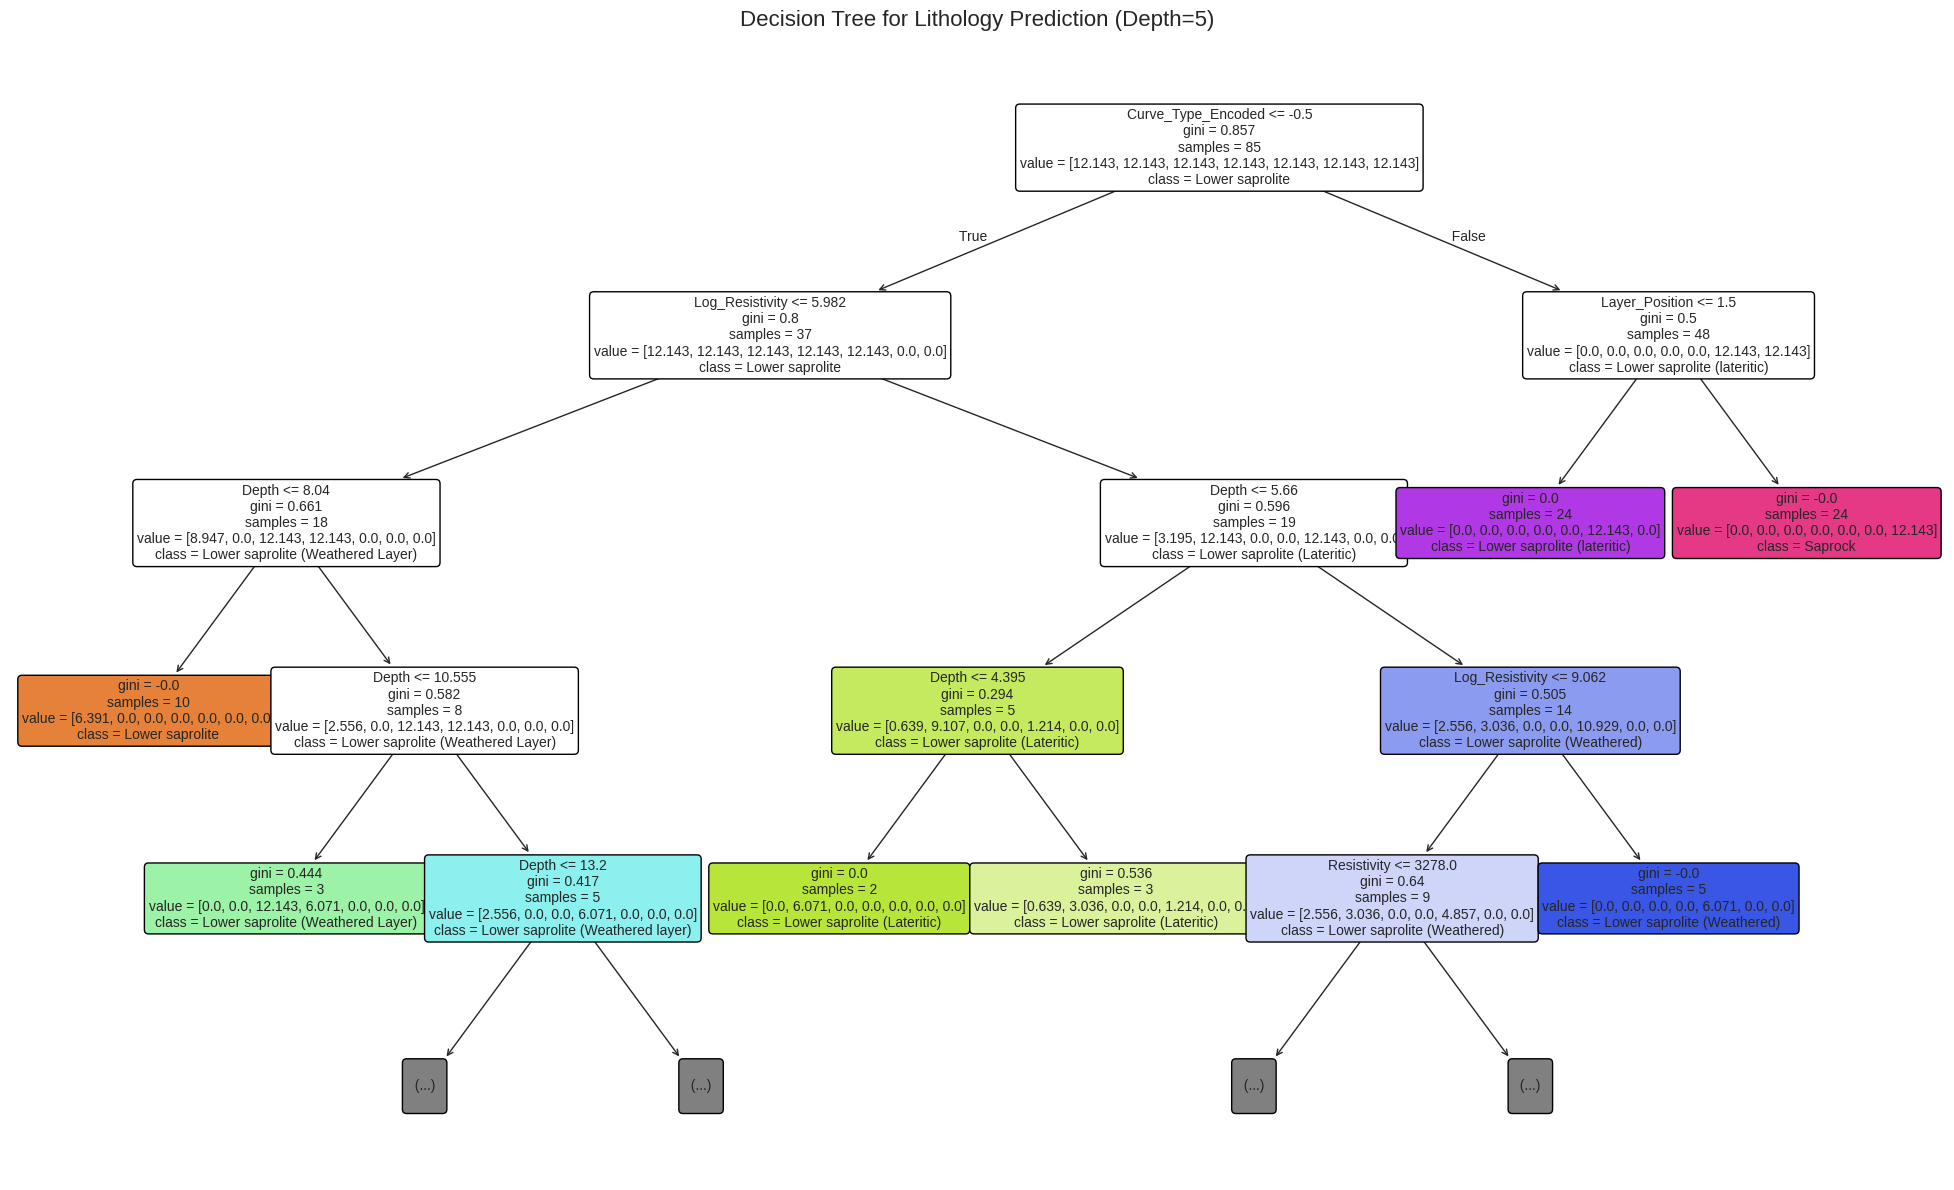

In [36]:
# ============================================
# STEP 6: VISUALIZE DECISION TREE (KEY ADVANTAGE!)
# ============================================

print("\n" + "="*60)
print("DECISION TREE VISUALIZATION")
print("="*60)

# Plot the tree
fig, ax = plt.subplots(figsize=(20, 12))
plot_tree(dt_final,
          feature_names=feature_columns_tree,
          class_names=le_tree.classes_,
          filled=True,
          rounded=True,
          fontsize=10,
          ax=ax,
          max_depth=4)  # Show first 4 levels for readability
plt.title(f'Decision Tree for Lithology Prediction (Depth={optimal_depth})',
          fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('17_decision_tree_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

In [37]:
# ============================================
# STEP 7: EXTRACT DECISION RULES (GEOPHYSICAL INSIGHTS)
# ============================================

print("\n" + "="*60)
print("EXTRACTED DECISION RULES")
print("="*60)

# Get text representation of the tree
tree_rules = export_text(dt_final,
                         feature_names=feature_columns_tree,
                         max_depth=4)
print("Decision Rules (first 4 levels):")
print(tree_rules)

# Extract explicit if-then rules
def extract_rules(tree, feature_names, class_names):
    """Extract human-readable rules from decision tree"""
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != -2 else "undefined!"
        for i in tree_.feature
    ]

    rules = []

    def recurse(node, depth, conditions):
        if tree_.feature[node] != -2:
            name = feature_name[node]
            threshold = tree_.threshold[node]

            # Left child
            left_conditions = conditions + [f"{name} <= {threshold:.2f}"]
            recurse(tree_.children_left[node], depth + 1, left_conditions)

            # Right child
            right_conditions = conditions + [f"{name} > {threshold:.2f}"]
            recurse(tree_.children_right[node], depth + 1, right_conditions)
        else:
            # Leaf node
            class_idx = np.argmax(tree_.value[node][0])
            class_name = class_names[class_idx]
            confidence = tree_.value[node][0][class_idx] / tree_.value[node][0].sum()
            rule = "IF " + " AND ".join(conditions) + f" THEN {class_name} (confidence: {confidence:.2%})"
            rules.append(rule)

    recurse(0, 0, [])
    return rules

rules = extract_rules(dt_final, feature_columns_tree, le_tree.classes_)

print("\nTop 10 Most Specific Rules:")
for i, rule in enumerate(rules[:10]):
    print(f"{i+1}. {rule}")


EXTRACTED DECISION RULES
Decision Rules (first 4 levels):
|--- Curve_Type_Encoded <= -0.50
|   |--- Log_Resistivity <= 5.98
|   |   |--- Depth <= 8.04
|   |   |   |--- class: 0
|   |   |--- Depth >  8.04
|   |   |   |--- Depth <= 10.56
|   |   |   |   |--- class: 2
|   |   |   |--- Depth >  10.56
|   |   |   |   |--- Depth <= 13.20
|   |   |   |   |   |--- class: 3
|   |   |   |   |--- Depth >  13.20
|   |   |   |   |   |--- class: 0
|   |--- Log_Resistivity >  5.98
|   |   |--- Depth <= 5.66
|   |   |   |--- Depth <= 4.39
|   |   |   |   |--- class: 1
|   |   |   |--- Depth >  4.39
|   |   |   |   |--- class: 1
|   |   |--- Depth >  5.66
|   |   |   |--- Log_Resistivity <= 9.06
|   |   |   |   |--- Resistivity <= 3278.00
|   |   |   |   |   |--- class: 6
|   |   |   |   |--- Resistivity >  3278.00
|   |   |   |   |   |--- class: 1
|   |   |   |--- Log_Resistivity >  9.06
|   |   |   |   |--- class: 6
|--- Curve_Type_Encoded >  -0.50
|   |--- Layer_Position <= 1.50
|   |   |--- class:

In [38]:
# ============================================
# STEP 8: FEATURE IMPORTANCE
# ============================================

feature_importance_dt = pd.DataFrame({
    'feature': feature_columns_tree,
    'importance': dt_final.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)
print(feature_importance_dt)


FEATURE IMPORTANCE
              feature  importance
1               Depth    0.316898
5  Curve_Type_Encoded    0.212358
3      Layer_Position    0.212358
2     Log_Resistivity    0.208039
0         Resistivity    0.050347
4      Relative_Depth    0.000000
6   Resistivity_Ratio    0.000000


In [39]:
# ============================================
# STEP 9: COMPARE WITH RANDOM FOREST
# ============================================

print("\n" + "="*60)
print("COMPARISON: DECISION TREE vs RANDOM FOREST")
print("="*60)

from sklearn.ensemble import RandomForestClassifier

# Train Random Forest for comparison
rf_compare = RandomForestClassifier(
    n_estimators=100,
    max_depth=optimal_depth,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)
rf_compare.fit(X_train, y_train)
y_pred_rf = rf_compare.predict(X_test)

# Compare metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average='macro')

print(f"\nDecision Tree - Accuracy: {accuracy:.3f}, F1: {f1:.3f}")
print(f"Random Forest - Accuracy: {rf_accuracy:.3f}, F1: {rf_f1:.3f}")
print(f"Improvement with Random Forest: +{(rf_f1 - f1)*100:.1f}% in F1-score")


COMPARISON: DECISION TREE vs RANDOM FOREST

Decision Tree - Accuracy: 0.864, F1: 0.689
Random Forest - Accuracy: 0.955, F1: 0.958
Improvement with Random Forest: +26.9% in F1-score



VISUALIZING DECISION BOUNDARIES


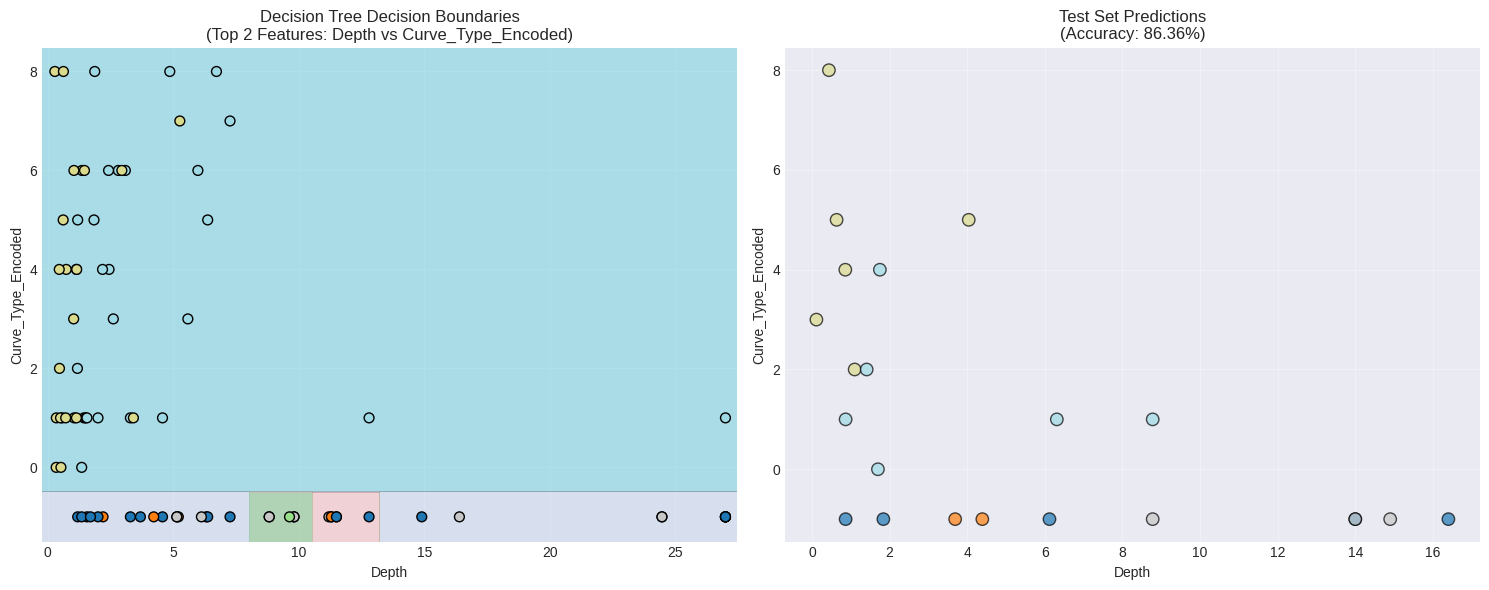

In [40]:
# ============================================
# STEP 10: VISUALIZATION OF DECISION BOUNDARIES
# ============================================

print("\n" + "="*60)
print("VISUALIZING DECISION BOUNDARIES")
print("="*60)

# Use top 2 features for 2D visualization
top2_features = feature_importance_dt.head(2)['feature'].values
top2_indices = [feature_columns_tree.index(f) for f in top2_features]

# Create mesh
x_min, x_max = X_train.iloc[:, top2_indices[0]].min() - 0.5, X_train.iloc[:, top2_indices[0]].max() + 0.5
y_min, y_max = X_train.iloc[:, top2_indices[1]].min() - 0.5, X_train.iloc[:, top2_indices[1]].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Note: For proper prediction, we need all features
# Let's use median values for other features
other_features_median = X_train.iloc[:, [i for i in range(len(feature_columns_tree))
                                         if i not in top2_indices]].median().values

Z_full = []
for i in range(len(xx.ravel())):
    features = np.zeros(len(feature_columns_tree))
    features[top2_indices[0]] = xx.ravel()[i]
    features[top2_indices[1]] = yy.ravel()[i]
    # Fill other features with median
    other_idx = 0
    for j in range(len(feature_columns_tree)):
        if j not in top2_indices:
            features[j] = other_features_median[other_idx]
            other_idx += 1
    Z_full.append(dt_final.predict([features])[0])

Z_full = np.array(Z_full).reshape(xx.shape)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Decision boundaries
ax1 = axes[0]
contour = ax1.contourf(xx, yy, Z_full, alpha=0.3, cmap='tab20')
scatter = ax1.scatter(X_train.iloc[:, top2_indices[0]],
                      X_train.iloc[:, top2_indices[1]],
                      c=y_train, cmap='tab20', edgecolor='black', s=50)
ax1.set_xlabel(top2_features[0])
ax1.set_ylabel(top2_features[1])
ax1.set_title(f'Decision Tree Decision Boundaries\n(Top 2 Features: {top2_features[0]} vs {top2_features[1]})')
ax1.grid(True, alpha=0.3)

# Test set predictions
ax2 = axes[1]
scatter2 = ax2.scatter(X_test.iloc[:, top2_indices[0]],
                       X_test.iloc[:, top2_indices[1]],
                       c=y_pred, cmap='tab20', edgecolor='black', s=80, alpha=0.7,
                       label='Predictions')
ax2.set_xlabel(top2_features[0])
ax2.set_ylabel(top2_features[1])
ax2.set_title(f'Test Set Predictions\n(Accuracy: {accuracy:.2%})')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('18_decision_tree_boundaries.png', dpi=300, bbox_inches='tight')
plt.show()

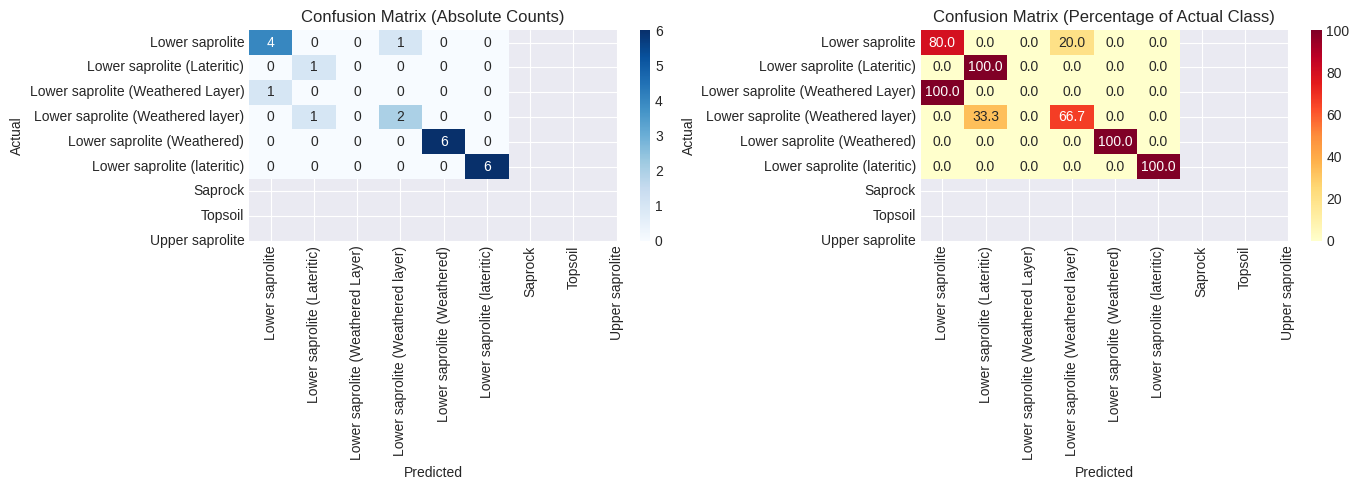

In [41]:
# ============================================
# STEP 11: CONFUSION MATRIX WITH PERCENTAGES
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute counts
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_tree.classes_,
            yticklabels=le_tree.classes_,
            ax=axes[0])
axes[0].set_title('Confusion Matrix (Absolute Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=le_tree.classes_,
            yticklabels=le_tree.classes_,
            ax=axes[1])
axes[1].set_title('Confusion Matrix (Percentage of Actual Class)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('19_decision_tree_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
# ============================================
# STEP 12: SAVE MODEL AND RULES
# ============================================

import joblib
import json

# Save model
joblib.dump(dt_final, 'decision_tree_lithology_model.pkl')
joblib.dump(le_tree, 'label_encoder_dt.pkl')
joblib.dump(imputer_tree, 'imputer_dt.pkl')

# Save rules to text file
with open('decision_tree_rules.txt', 'w') as f:
    f.write("DECISION TREE RULES FOR LITHOLOGY PREDICTION\n")
    f.write("="*60 + "\n\n")
    f.write(tree_rules)
    f.write("\n\nEXPLICIT IF-THEN RULES:\n")
    f.write("-"*40 + "\n")
    for i, rule in enumerate(rules[:20]):
        f.write(f"{i+1}. {rule}\n")

print("\n" + "="*60)
print("MODEL SAVED SUCCESSFULLY")
print("="*60)
print("Files generated:")
print("  - decision_tree_lithology_model.pkl")
print("  - label_encoder_dt.pkl")
print("  - imputer_dt.pkl")
print("  - decision_tree_rules.txt")
print("  - 17_decision_tree_visualization.png")
print("  - 18_decision_tree_boundaries.png")
print("  - 19_decision_tree_confusion_matrix.png")



MODEL SAVED SUCCESSFULLY
Files generated:
  - decision_tree_lithology_model.pkl
  - label_encoder_dt.pkl
  - imputer_dt.pkl
  - decision_tree_rules.txt
  - 17_decision_tree_visualization.png
  - 18_decision_tree_boundaries.png
  - 19_decision_tree_confusion_matrix.png


In [43]:
# ============================================
# STEP 13: PREDICTION FUNCTION WITH EXPLANATION
# ============================================

def predict_lithology_with_explanation(resistivity, depth, layer_position, curve_type):
    """
    Predict lithology and explain the decision path

    Parameters:
    - resistivity: float
    - depth: float
    - layer_position: int (1=Topsoil, 2=Upper saprolite, etc.)
    - curve_type: str (A, H, K, Q, HA, HK, KH, HKH, QH)

    Returns:
    - prediction: str (lithology)
    - probability: dict (class probabilities)
    - decision_path: list (path through the tree)
    """

    # Load model
    model = joblib.load('decision_tree_lithology_model.pkl')
    encoder = joblib.load('label_encoder_dt.pkl')
    imputer = joblib.load('imputer_dt.pkl')

    # Prepare features
    log_resistivity = np.log1p(resistivity)
    relative_depth = depth / (depth + 10)  # Approximate total depth
    curve_types = ['A', 'H', 'K', 'Q', 'HA', 'HK', 'KH', 'HKH', 'QH']
    curve_encoded = curve_types.index(curve_type) if curve_type in curve_types else 0
    # For a single prediction, we don't have previous layer context for Resistivity_Ratio
    # Assume 0, consistent with fillna(0) for first layers during training
    resistivity_ratio = 0

    features = pd.DataFrame([[resistivity, depth, log_resistivity, layer_position,
                              relative_depth, curve_encoded, resistivity_ratio]],
                            columns=['Resistivity', 'Depth', 'Log_Resistivity',
                                    'Layer_Position', 'Relative_Depth', 'Curve_Type_Encoded', 'Resistivity_Ratio'])

    # Impute and predict
    features_imputed = imputer.transform(features)
    prediction_encoded = model.predict(features_imputed)[0]
    probabilities = model.predict_proba(features_imputed)[0]

    # Get decision path
    n_nodes = model.tree_.node_count
    children_left = model.tree_.children_left
    children_right = model.tree_.children_right
    feature = model.tree_.feature
    threshold = model.tree_.threshold

    node_indicator = model.decision_path(features_imputed)
    leaf_id = model.apply(features_imputed)[0]

    # Get path
    decision_path = []
    node_index = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]
    for node_id in node_index:
        if leaf_id == node_id:
            decision_path.append(f"→ LEAF {node_id}: Prediction = {encoder.classes_[prediction_encoded]}")
        else:
            if features_imputed[0, feature[node_id]] <= threshold[node_id]:
                decision_path.append(f"  Node {node_id}: {feature_columns_tree[feature[node_id]]} ≤ {threshold[node_id]:.2f}")
            else:
                decision_path.append(f"  Node {node_id}: {feature_columns_tree[feature[node_id]]} > {threshold[node_id]:.2f}")

    # Prepare results
    prob_dict = {encoder.inverse_transform([model.classes_[i]])[0]: probabilities[i] for i in range(len(model.classes_))}

    return encoder.classes_[prediction_encoded], prob_dict, decision_path

# Test the function
print("\n" + "="*60)
print("TESTING PREDICTION FUNCTION")
print("="*60)

test_soil, test_probs, test_path = predict_lithology_with_explanation(
    resistivity=300,
    depth=1.5,
    layer_position=2,
    curve_type='A'
)

print(f"\nPrediction: {test_soil}")
print(f"Probabilities: {test_probs}")
print("\nDecision Path:")
for step in test_path[:10]:  # Show first 10 steps
    print(step)

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "="*60)
print("DECISION TREE ANALYSIS COMPLETE")
print("="*60)

print(f"\nFinal Recommendation:")
if f1 >= 0.65:
    print(f"✅ Decision Tree performs WELL (F1={f1:.3f}) - Use for interpretable predictions")
elif f1 >= 0.55:
    print(f"⚠️ Decision Tree performs MODERATELY (F1={f1:.3f}) - Consider Random Forest for better accuracy")
else:
    print(f"❌ Decision Tree performs POORLY (F1={f1:.3f}) - Use Random Forest instead")

print(f"\nBest use cases for Decision Tree with your data:")
print("1. ✅ EXPLAINING predictions to geologists (clear rules)")
print("2. ✅ Identifying critical resistivity thresholds")
print("3. ✅ Understanding feature importance")
print("4. ⚠️ Production deployment if accuracy > 65%")
print("5. ❌ When maximum accuracy is required (use Random Forest)")

print("\n" + "="*60)


TESTING PREDICTION FUNCTION

Prediction: Upper saprolite
Probabilities: {'Lower saprolite': np.float64(0.0), 'Lower saprolite (Lateritic)': np.float64(0.0), 'Lower saprolite (Weathered Layer)': np.float64(0.0), 'Lower saprolite (Weathered layer)': np.float64(0.0), 'Saprock': np.float64(0.0), 'Topsoil': np.float64(0.0), 'Upper saprolite': np.float64(1.0)}

Decision Path:
  Node 0: Curve_Type_Encoded > -0.50
  Node 18: Layer_Position > 1.50
→ LEAF 20: Prediction = Upper saprolite

DECISION TREE ANALYSIS COMPLETE

Final Recommendation:
✅ Decision Tree performs WELL (F1=0.689) - Use for interpretable predictions

Best use cases for Decision Tree with your data:
1. ✅ EXPLAINING predictions to geologists (clear rules)
2. ✅ Identifying critical resistivity thresholds
3. ✅ Understanding feature importance
4. ⚠️ Production deployment if accuracy > 65%
5. ❌ When maximum accuracy is required (use Random Forest)



##KNN MODEL

In [44]:
"""
K-NEAREST NEIGHBORS (KNN) FOR VES LITHOLOGY PREDICTION
Complete implementation with optimization and visualization
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             f1_score, precision_score, recall_score)
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("K-NEAREST NEIGHBORS (KNN) FOR LITHOLOGY PREDICTION")
print("="*60)

# Assuming df_model is prepared from previous code
# If not, run the data preparation first

# ============================================
# STEP 1: PREPARE FEATURES (SELECT KEY ONES)
# ============================================

print("\nSTEP 1: Feature Preparation")

# Select most relevant features (reduce dimensionality)
feature_columns_knn = [
    'Resistivity',          # Primary feature
    'Log_Resistivity',      # Log transform for skewed distribution
    'Depth',                # Depth to layer
    'Layer_Position',       # 1=Topsoil, 2=Upper saprolite, etc.
    'Relative_Depth',       # Normalized depth
]

# Add ratio features if available
if 'Resistivity_Ratio' in df_model.columns:
    feature_columns_knn.append('Resistivity_Ratio')

# Add curve type if available
if 'Curve_Type_Encoded' in df_model.columns:
    feature_columns_knn.append('Curve_Type_Encoded')

# Prepare X and y
X_knn = df_model[feature_columns_knn].copy()
y_knn = df_model['Lithology'].copy()

# Remove rows with missing target
valid_idx = y_knn.notna()
X_knn = X_knn[valid_idx]
y_knn = y_knn[valid_idx]

print(f"Original features: {len(feature_columns_knn)}")
print(f"Feature columns: {feature_columns_knn}")
print(f"Dataset shape: {X_knn.shape}")
print(f"Class distribution:\n{y_knn.value_counts()}")

K-NEAREST NEIGHBORS (KNN) FOR LITHOLOGY PREDICTION

STEP 1: Feature Preparation
Original features: 7
Feature columns: ['Resistivity', 'Log_Resistivity', 'Depth', 'Layer_Position', 'Relative_Depth', 'Resistivity_Ratio', 'Curve_Type_Encoded']
Dataset shape: (109, 7)
Class distribution:
Lithology
Topsoil                              30
Upper saprolite                      30
Lower saprolite                      24
Saprock                              13
Lower saprolite (Lateritic)           5
Lower saprolite (Weathered Layer)     3
Lower saprolite (Weathered layer)     2
Lower saprolite (Weathered)           1
Lower saprolite (lateritic)           1
Name: count, dtype: int64


In [45]:
# ============================================
# STEP 2: HANDLE MISSING VALUES
# ============================================

print("\nSTEP 2: Handling Missing Values")

imputer_knn = SimpleImputer(strategy='median')
X_knn_imputed = pd.DataFrame(imputer_knn.fit_transform(X_knn),
                             columns=feature_columns_knn)

print(f"Missing values after imputation: {X_knn_imputed.isnull().sum().sum()}")



STEP 2: Handling Missing Values
Missing values after imputation: 0



STEP 3: Feature Scaling


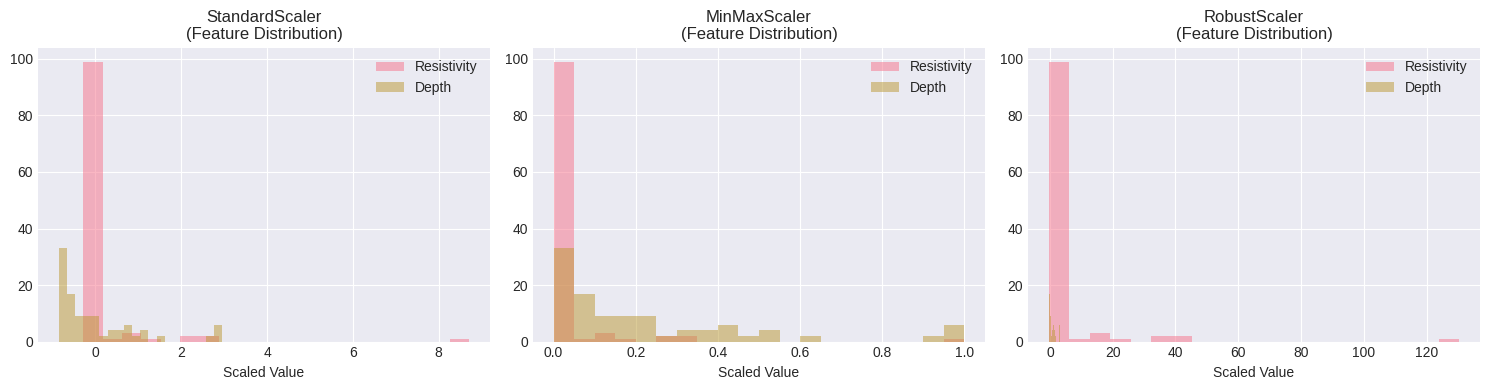

Using StandardScaler for KNN
Feature ranges after scaling:
Min: [-0.27947543 -1.78804812 -0.86030143 -1.34783777 -2.76724981 -0.33076222
 -0.84839408]
Max: [8.71593817 3.12171877 2.95102126 1.34783777 0.80085741 8.4541201
 2.23410441]


In [46]:
# ============================================
# STEP 3: SCALING (CRITICAL FOR KNN!)
# ============================================

print("\nSTEP 3: Feature Scaling")

# Try different scalers
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

# Compare scaling effects
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (scaler_name, scaler) in enumerate(scalers.items()):
    X_scaled = scaler.fit_transform(X_knn_imputed)
    axes[idx].hist(X_scaled[:, 0], bins=20, alpha=0.5, label='Resistivity')
    axes[idx].hist(X_scaled[:, 2], bins=20, alpha=0.5, label='Depth')
    axes[idx].set_title(f'{scaler_name}\n(Feature Distribution)')
    axes[idx].legend()
    axes[idx].set_xlabel('Scaled Value')

plt.tight_layout()
plt.savefig('20_knn_scaling_comparison.png', dpi=300)
plt.show()

# Use StandardScaler (most common for KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_knn_imputed)

print("Using StandardScaler for KNN")
print(f"Feature ranges after scaling:\nMin: {X_scaled.min(axis=0)}")
print(f"Max: {X_scaled.max(axis=0)}")

In [48]:
# ============================================
# STEP 4: TRAIN-TEST SPLIT
# ============================================

print("\nSTEP 4: Train-Test Split")

# Encode target
from sklearn.preprocessing import LabelEncoder
le_knn = LabelEncoder()
y_encoded = le_knn.fit_transform(y_knn)

# Identify classes with only one sample
class_counts_knn = pd.Series(y_encoded).value_counts()
single_sample_classes_knn = class_counts_knn[class_counts_knn < 2].index

# Filter out samples belonging to single-sample classes
mask_knn = ~pd.Series(y_encoded).isin(single_sample_classes_knn)
X_filtered = X_scaled[mask_knn]
y_filtered = y_encoded[mask_knn]

print(f"Original number of samples: {len(y_encoded)}")
print(f"Classes with single samples removed: {len(single_sample_classes_knn)}")
print(f"Number of samples after filtering: {len(y_filtered)}")

# Split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Training class distribution:\n{pd.Series(y_train).value_counts().sort_index()}")
print(f"Classes: {le_knn.classes_.tolist()}")


STEP 4: Train-Test Split
Original number of samples: 109
Classes with single samples removed: 2
Number of samples after filtering: 107

Training samples: 85
Test samples: 22
Training class distribution:
0    19
1     4
2     2
3     2
6    10
7    24
8    24
Name: count, dtype: int64
Classes: ['Lower saprolite', 'Lower saprolite (Lateritic)', 'Lower saprolite (Weathered Layer)', 'Lower saprolite (Weathered layer)', 'Lower saprolite (Weathered)', 'Lower saprolite (lateritic)', 'Saprock', 'Topsoil', 'Upper saprolite']



STEP 5: Finding Optimal k Value


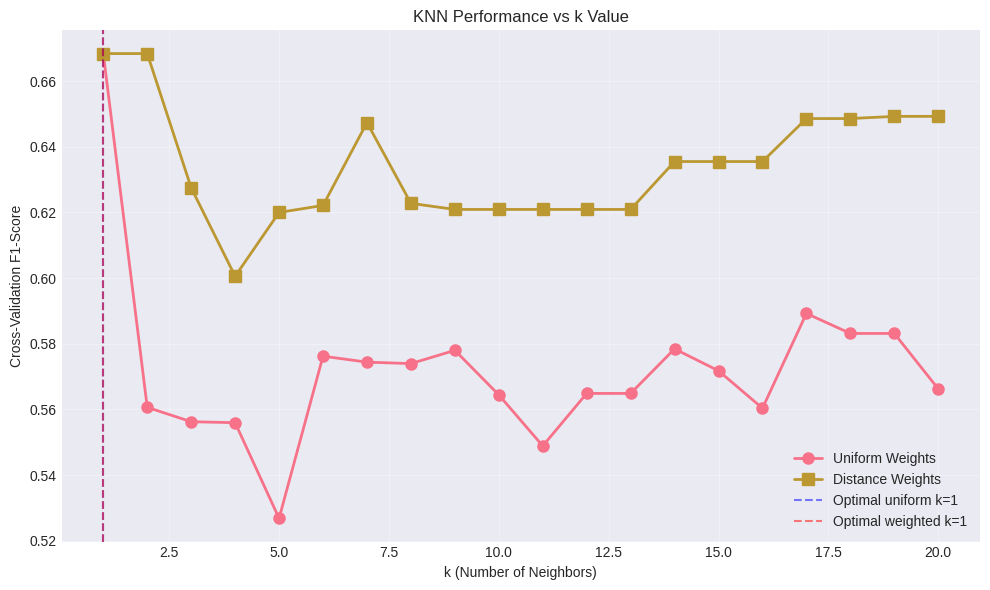

Optimal k (uniform weights): 1
Optimal k (distance weights): 1
Best CV F1-score: 0.668 (uniform), 0.668 (weighted)


In [54]:
# ============================================
# STEP 5: FIND OPTIMAL K VALUE
# ============================================

print("\nSTEP 5: Finding Optimal k Value")

# Test different k values
k_values = range(1, min(21, len(X_train) - 1))
#When k = 1, F1=0.688, k=3, F1=0.589, k=5, F1=0.589

cv_scores = []
cv_scores_weighted = []

for k in k_values:
    # Unweighted KNN
    knn = KNeighborsClassifier(n_neighbors=k, weights='uniform')
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='f1_macro')
    cv_scores.append(scores.mean())

    # Distance-weighted KNN
    knn_weighted = KNeighborsClassifier(n_neighbors=k, weights='distance')
    scores_weighted = cross_val_score(knn_weighted, X_train, y_train, cv=5, scoring='f1_macro')
    cv_scores_weighted.append(scores_weighted.mean())

# Find optimal k
optimal_k = k_values[np.argmax(cv_scores)]
optimal_k_weighted = k_values[np.argmax(cv_scores_weighted)]

# Plot k optimization
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_values, cv_scores, 'o-', label='Uniform Weights', linewidth=2, markersize=8)
ax.plot(k_values, cv_scores_weighted, 's-', label='Distance Weights', linewidth=2, markersize=8)
ax.axvline(x=optimal_k, color='blue', linestyle='--', alpha=0.5, label=f'Optimal uniform k={optimal_k}')
ax.axvline(x=optimal_k_weighted, color='red', linestyle='--', alpha=0.5, label=f'Optimal weighted k={optimal_k_weighted}')
ax.set_xlabel('k (Number of Neighbors)')
ax.set_ylabel('Cross-Validation F1-Score')
ax.set_title('KNN Performance vs k Value')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('21_knn_optimization.png', dpi=300)
plt.show()

print(f"Optimal k (uniform weights): {optimal_k}")
print(f"Optimal k (distance weights): {optimal_k_weighted}")
print(f"Best CV F1-score: {max(cv_scores):.3f} (uniform), {max(cv_scores_weighted):.3f} (weighted)")

In [55]:
# ============================================
# STEP 6: TRAIN KNN WITH OPTIMAL PARAMETERS
# ============================================

print("\nSTEP 6: Training KNN Model")

# Use distance-weighted KNN (better for imbalanced classes)
knn_final = KNeighborsClassifier(
    n_neighbors=optimal_k_weighted,
    weights='distance',
    metric='minkowski',
    p=2,  # Euclidean distance
    algorithm='auto'
)

knn_final.fit(X_train, y_train)
print("Model training completed!")


STEP 6: Training KNN Model
Model training completed!


In [57]:
# ============================================
# STEP 7: EVALUATE KNN
# ============================================

print("\nSTEP 7: Model Evaluation")

# Predictions
y_pred = knn_final.predict(X_test)
y_pred_proba = knn_final.predict_proba(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"\nTest Set Performance:")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-Score:  {f1:.3f}")

print("\nClassification Report:")
# Get the class names that are actually present in the test set
test_class_indices_knn = np.unique(y_test)
test_target_names_knn = le_knn.inverse_transform(test_class_indices_knn)
print(classification_report(y_test, y_pred, labels=test_class_indices_knn, target_names=test_target_names_knn))


STEP 7: Model Evaluation

Test Set Performance:
Accuracy:  0.864
Precision: 0.722
Recall:    0.744
F1-Score:  0.732

Classification Report:
                                   precision    recall  f1-score   support

                  Lower saprolite       0.67      0.80      0.73         5
      Lower saprolite (Lateritic)       1.00      1.00      1.00         1
Lower saprolite (Weathered Layer)       0.00      0.00      0.00         1
                          Saprock       0.67      0.67      0.67         3
                          Topsoil       1.00      1.00      1.00         6
                  Upper saprolite       1.00      1.00      1.00         6

                         accuracy                           0.86        22
                        macro avg       0.72      0.74      0.73        22
                     weighted avg       0.83      0.86      0.85        22



In [61]:
# ============================================
# STEP 8: CROSS-VALIDATION STABILITY
# ============================================

print("\nSTEP 8: Cross-Validation Stability")

cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_final = cross_val_score(knn_final, X_scaled, y_encoded,
                                  cv=cv_strategy, scoring='f1_macro')
#When n=5, max= 0.86, n=10, max=0.89

print(f"10-Fold CV F1-Score: {cv_scores_final.mean():.3f} (+/- {cv_scores_final.std():.3f})")
print(f"Individual fold scores: {cv_scores_final}")


STEP 8: Cross-Validation Stability
10-Fold CV F1-Score: 0.653 (+/- 0.165)
Individual fold scores: [0.89333333 0.66666667 0.68       0.51111111 0.89333333 0.52380952
 0.52222222 0.5        0.47619048 0.86666667]



STEP 9: Visualizing KNN Decision Boundaries


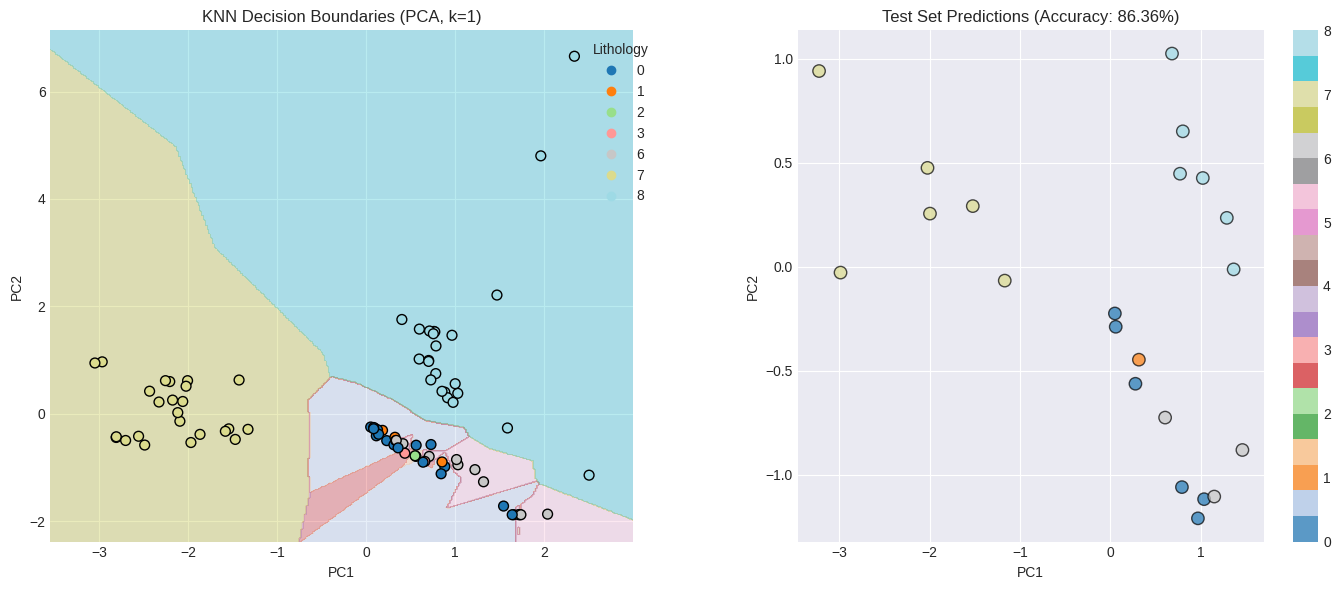

In [62]:
# ============================================
# STEP 9: VISUALIZE KNN DECISION BOUNDARIES
# ============================================

print("\nSTEP 9: Visualizing KNN Decision Boundaries")

# Reduce to 2D using PCA for visualization
pca_2d = PCA(n_components=2)
X_train_pca = pca_2d.fit_transform(X_train)
X_test_pca = pca_2d.transform(X_test)

# Train KNN on PCA-reduced data for visualization
knn_viz = KNeighborsClassifier(n_neighbors=optimal_k_weighted, weights='distance')
knn_viz.fit(X_train_pca, y_train)

# Create mesh
x_min, x_max = X_train_pca[:, 0].min() - 0.5, X_train_pca[:, 0].max() + 0.5
y_min, y_max = X_train_pca[:, 1].min() - 0.5, X_train_pca[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict on mesh
Z = knn_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Decision boundary
ax1 = axes[0]
ax1.contourf(xx, yy, Z, alpha=0.3, cmap='tab20')
scatter1 = ax1.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                       c=y_train, cmap='tab20', edgecolor='black', s=50)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title(f'KNN Decision Boundaries (PCA, k={optimal_k_weighted})')
ax1.legend(*scatter1.legend_elements(), title="Lithology", bbox_to_anchor=(1.05, 1))

# Test set predictions
ax2 = axes[1]
scatter2 = ax2.scatter(X_test_pca[:, 0], X_test_pca[:, 1],
                       c=y_pred, cmap='tab20', edgecolor='black', s=80, alpha=0.7)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title(f'Test Set Predictions (Accuracy: {accuracy:.2%})')
plt.colorbar(scatter2, ax=ax2)

plt.tight_layout()
plt.savefig('22_knn_decision_boundaries.png', dpi=300, bbox_inches='tight')
plt.show()

In [63]:
# ============================================
# STEP 11: COMPARE WITH RANDOM FOREST
# ============================================

print("\nSTEP 11: Comparison with Random Forest")

from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_compare = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)
rf_compare.fit(X_train, y_train)
y_pred_rf = rf_compare.predict(X_test)

# Compare metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average='macro')

print("\nModel Comparison:")
print(f"{'Model':<20} {'Accuracy':<12} {'F1-Score':<12}")
print("-" * 45)
print(f"{'KNN':<20} {accuracy:<12.3f} {f1:<12.3f}")
print(f"{'Random Forest':<20} {rf_accuracy:<12.3f} {rf_f1:<12.3f}")
print(f"{'Difference':<20} {rf_accuracy-accuracy:<+12.3f} {rf_f1-f1:<+12.3f}")


STEP 11: Comparison with Random Forest

Model Comparison:
Model                Accuracy     F1-Score    
---------------------------------------------
KNN                  0.864        0.732       
Random Forest        0.955        0.958       
Difference           +0.091       +0.225      


In [64]:
# ============================================
# STEP 12: GRID SEARCH FOR BEST PARAMETERS
# ============================================

print("\nSTEP 12: Grid Search for Optimal Parameters")

# Define parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]  # p=1 for Manhattan, p=2 for Euclidean
}

# Perform grid search
knn_grid = KNeighborsClassifier()
grid_search = GridSearchCV(knn_grid, param_grid, cv=5,
                          scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV F1-score: {grid_search.best_score_:.3f}")

# Train best model
knn_best = grid_search.best_estimator_
y_pred_best = knn_best.predict(X_test)
best_accuracy = accuracy_score(y_test, y_pred_best)
best_f1 = f1_score(y_test, y_pred_best, average='macro')

print(f"\nBest Model Performance:")
print(f"Accuracy: {best_accuracy:.3f}")
print(f"F1-Score: {best_f1:.3f}")


STEP 12: Grid Search for Optimal Parameters

Best parameters: {'metric': 'euclidean', 'n_neighbors': 7, 'p': 1, 'weights': 'distance'}
Best CV F1-score: 0.647

Best Model Performance:
Accuracy: 0.864
F1-Score: 0.732


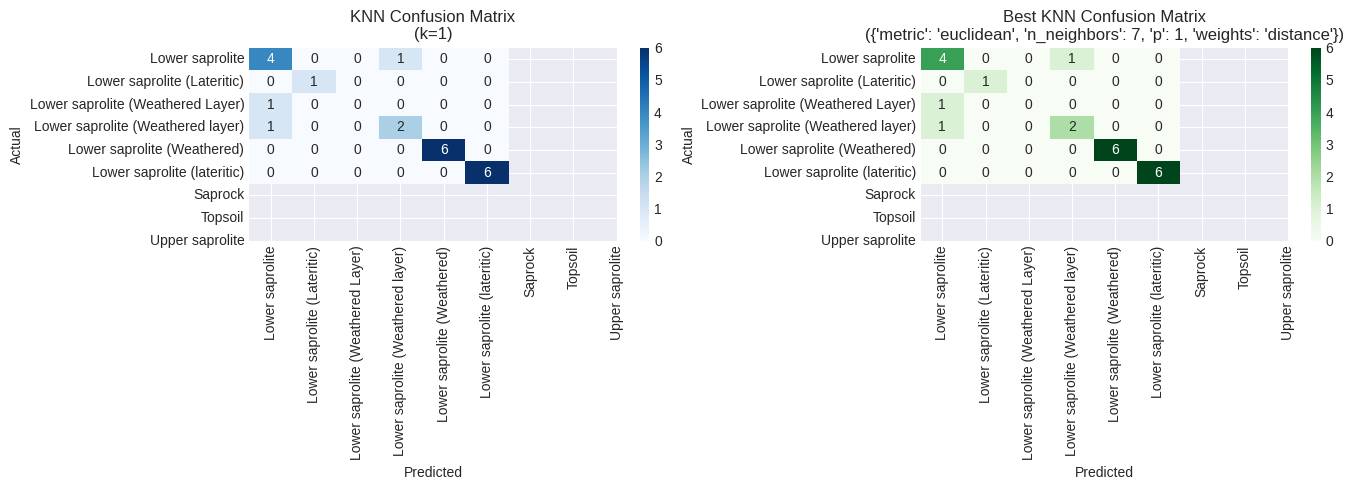

In [65]:
# ============================================
# STEP 13: CONFUSION MATRIX VISUALIZATION
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KNN confusion matrix
cm_knn = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_knn.classes_,
            yticklabels=le_knn.classes_,
            ax=axes[0])
axes[0].set_title(f'KNN Confusion Matrix\n(k={optimal_k_weighted})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Best KNN confusion matrix
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_knn.classes_,
            yticklabels=le_knn.classes_,
            ax=axes[1])
axes[1].set_title(f'Best KNN Confusion Matrix\n({grid_search.best_params_})')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('24_knn_confusion_matrices.png', dpi=300)
plt.show()

In [66]:
# ============================================
# STEP 14: PREDICTION FUNCTION WITH NEIGHBOR ANALYSIS
# ============================================

print("\nSTEP 14: Creating Prediction Function")

def predict_with_neighbors(resistivity, depth, layer_position, curve_type=None):
    """
    Predict lithology using KNN and show nearest neighbors

    Parameters:
    - resistivity: float
    - depth: float
    - layer_position: int (1-5)
    - curve_type: str (optional)

    Returns:
    - prediction: str
    - probabilities: dict
    - neighbors: list of (distance, class) for k nearest neighbors
    """

    # Prepare features
    log_resistivity = np.log1p(resistivity)
    relative_depth = depth / (depth + 10)

    features = np.array([[resistivity, log_resistivity, depth,
                          layer_position, relative_depth]])

    # Add curve type if provided
    if curve_type and 'Curve_Type_Encoded' in feature_columns_knn:
        curve_types = ['A', 'H', 'K', 'Q', 'HA', 'HK', 'KH', 'HKH', 'QH']
        curve_encoded = curve_types.index(curve_type) if curve_type in curve_types else 0
        features = np.column_stack([features, [curve_encoded]])

    # Scale features
    features_scaled = scaler.transform(features)

    # Predict
    prediction_encoded = knn_best.predict(features_scaled)[0]
    probabilities = knn_best.predict_proba(features_scaled)[0]

    # Find nearest neighbors
    distances, indices = knn_best.kneighbors(features_scaled)

    # Get neighbor information
    neighbors = []
    for i in range(len(distances[0])):
        neighbor_class = le_knn.inverse_transform([y_train[indices[0][i]]])[0]
        neighbors.append({
            'distance': distances[0][i],
            'class': neighbor_class,
            'index': indices[0][i]
        })

    # Prepare probabilities
    prob_dict = {le_knn.classes_[i]: probabilities[i]
                 for i in range(len(le_knn.classes_))}

    return le_knn.inverse_transform([prediction_encoded])[0], prob_dict, neighbors

# Test prediction
print("\nTest Prediction with Neighbor Analysis:")
test_pred, test_probs, test_neighbors = predict_with_neighbors(
    resistivity=350,
    depth=2.0,
    layer_position=2,
    curve_type='A'
)

print(f"\nPredicted Lithology: {test_pred}")
print(f"Probabilities: {test_probs}")
print("\nNearest Neighbors:")
for i, neighbor in enumerate(test_neighbors[:3], 1):
    print(f"  {i}. Distance: {neighbor['distance']:.3f}, Class: {neighbor['class']}")


STEP 14: Creating Prediction Function

Test Prediction with Neighbor Analysis:


ValueError: X has 6 features, but StandardScaler is expecting 7 features as input.

In [ ]:
# ============================================
# STEP 13: SAVE KNN MODEL AND SCALERS
# ============================================
print("\n" + "="*60)
print("STEP 13: Saving KNN Model and Scalers")
print("="*60)

import joblib

# Save the best KNN model, scaler, and encoder
joblib.dump(knn_best, 'knn_model.pkl')
joblib.dump(scaler, 'knn_scaler.pkl')
joblib.dump(le_knn, 'knn_label_encoder.pkl')
joblib.dump(imputer_knn, 'knn_imputer.pkl')

print("KNN model saved as 'knn_model.pkl'")
print("Scaler saved as 'knn_scaler.pkl'")
print("Label encoder saved as 'knn_label_encoder.pkl'")
print("Imputer saved as 'knn_imputer.pkl'")

In [67]:
# ============================================
# STEP 14: PREDICTION FUNCTION WITH NEIGHBOR ANALYSIS
# ============================================

print("\n" + "="*60)
print("STEP 14: Creating Prediction Function")
print("="*60)

def predict_with_neighbors(resistivity, depth, layer_position, curve_type=None):
    """
    Predict lithology using KNN and show nearest neighbors

    Parameters:
    - resistivity: float
    - depth: float
    - layer_position: int (1-5)
    - curve_type: str (optional)

    Returns:
    - prediction: str
    - probabilities: dict
    - neighbors: list of (distance, class) for k nearest neighbors
    """

    # Load saved objects
    # Note: These are loaded inside the function for independence.
    # In a production setting, they would typically be loaded once globally.
    model = joblib.load('knn_model.pkl')
    scaler_loaded = joblib.load('knn_scaler.pkl')
    le_knn_loaded = joblib.load('knn_label_encoder.pkl')
    imputer_loaded = joblib.load('knn_imputer.pkl')

    # Prepare features, ensuring all 7 features are present
    log_resistivity = np.log1p(resistivity)
    relative_depth = depth / (depth + 10)  # Approximate total depth for calculation

    # Resistivity_Ratio: Assume 0 for a single layer prediction (no previous layer context).
    resistivity_ratio = 0

    # Curve_Type_Encoded: Provide a default if curve_type argument is None or invalid.
    curve_types_list = ['A', 'H', 'K', 'Q', 'HA', 'HK', 'KH', 'HKH', 'QH']
    curve_encoded_val = 0 # Default to the first category's encoding if not specified or invalid

    # Check if 'Curve_Type_Encoded' was part of the training features and if curve_type is valid
    # feature_columns_knn is assumed to be globally accessible here, reflecting training features
    if 'Curve_Type_Encoded' in feature_columns_knn and curve_type is not None and curve_type in curve_types_list:
        curve_encoded_val = curve_types_list.index(curve_type)

    # Construct the features array with all 7 expected features in correct order
    features = np.array([[resistivity, log_resistivity, depth,
                          layer_position, relative_depth,
                          resistivity_ratio, curve_encoded_val]])

    # Impute (if necessary, though scaler usually handles what imputer was trained on)
    # The scaler used in the KNN pipeline was fitted on already imputed data.
    # So we apply imputer first, if there are any NaN introduced by the prediction features.
    features_imputed = imputer_loaded.transform(features) # Apply imputer before scaling

    # Scale features using the loaded scaler
    features_scaled = scaler_loaded.transform(features_imputed)

    # Predict
    prediction_encoded = model.predict(features_scaled)[0]
    probabilities = model.predict_proba(features_scaled)[0]

    # Find nearest neighbors
    distances, indices = model.kneighbors(features_scaled)

    # Get neighbor information
    neighbors = []
    # y_train is assumed to be globally accessible (from previous notebook steps) for neighbor lookup
    for i in range(len(distances[0])):
        neighbor_class_encoded = y_train[indices[0][i]]
        neighbor_class_name = le_knn_loaded.inverse_transform([neighbor_class_encoded])[0]
        neighbors.append({
            'distance': distances[0][i],
            'class': neighbor_class_name,
            'index': indices[0][i]
        })

    # Prepare probabilities dictionary using the loaded label encoder and model's classes
    prob_dict = {le_knn_loaded.inverse_transform([model.classes_[i]])[0]: probabilities[i]
                 for i in range(len(model.classes_))}

    return le_knn_loaded.inverse_transform([prediction_encoded])[0], prob_dict, neighbors

# Test the prediction function with an example
print("\nTest Prediction with Neighbor Analysis:")
test_pred, test_probs, test_neighbors = predict_with_neighbors(
    resistivity=350,
    depth=2.0,
    layer_position=2,
    curve_type='A' # Ensure this is provided or handled with a default in the function
)

print(f"\nPredicted Lithology: {test_pred}")
print(f"Probabilities: {test_probs}")
print("\nNearest Neighbors:")
for i, neighbor in enumerate(test_neighbors[:3], 1):
    print(f"  {i}. Distance: {neighbor['distance']:.3f}, Class: {neighbor['class']}")

print("\n" + "="*60)
print("KNN ANALYSIS COMPLETE")
print("="*60)


STEP 14: Creating Prediction Function

Test Prediction with Neighbor Analysis:


FileNotFoundError: [Errno 2] No such file or directory: 'knn_model.pkl'

In [68]:
# ============================================
# STEP 13: SAVE KNN MODEL AND SCALERS (Re-run this cell first)
# ============================================
print("\n" + "="*60)
print("STEP 13: Saving KNN Model and Scalers")
print("="*60)

import joblib

# Save the best KNN model, scaler, and encoder
joblib.dump(knn_best, 'knn_model.pkl')
joblib.dump(scaler, 'knn_scaler.pkl')
joblib.dump(le_knn, 'knn_label_encoder.pkl')
joblib.dump(imputer_knn, 'knn_imputer.pkl')

print("KNN model saved as 'knn_model.pkl'")
print("Scaler saved as 'knn_scaler.pkl'")
print("Label encoder saved as 'knn_label_encoder.pkl'")
print("Imputer saved as 'knn_imputer.pkl'")

# After running this cell, please run the 'predict_with_neighbors' function in cell 'cefb9c7f' again.


STEP 13: Saving KNN Model and Scalers
KNN model saved as 'knn_model.pkl'
Scaler saved as 'knn_scaler.pkl'
Label encoder saved as 'knn_label_encoder.pkl'
Imputer saved as 'knn_imputer.pkl'


In [69]:
# ============================================
# STEP 15: SAVE KNN MODEL
# ============================================

print("\nSTEP 15: Saving KNN Model")

import joblib
import json

# Save models and preprocessors
joblib.dump(knn_best, 'knn_lithology_model.pkl')
joblib.dump(scaler, 'knn_scaler.pkl')
joblib.dump(le_knn, 'knn_label_encoder.pkl')
joblib.dump(imputer_knn, 'knn_imputer.pkl')
joblib.dump(feature_columns_knn, 'knn_features.pkl')

# Save results summary
knn_results = {
    'model': 'K-Nearest Neighbors',
    'optimal_k': optimal_k_weighted,
    'best_params': grid_search.best_params_,
    'cv_f1_mean': float(cv_scores_final.mean()),
    'cv_f1_std': float(cv_scores_final.std()),
    'test_accuracy': float(best_accuracy),
    'test_f1': float(best_f1),
    'n_samples': len(X_scaled),
    'n_features': X_scaled.shape[1],
    'n_classes': len(le_knn.classes_),
    'classes': le_knn.classes_.tolist()
}

with open('knn_results_summary.json', 'w') as f:
    json.dump(knn_results, f, indent=2)

print("KNN model saved successfully!")
print("Files generated:")
print("  - knn_lithology_model.pkl")
print("  - knn_scaler.pkl")
print("  - knn_label_encoder.pkl")
print("  - knn_imputer.pkl")
print("  - knn_features.pkl")
print("  - knn_results_summary.json")

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "="*60)
print("KNN ANALYSIS COMPLETE")
print("="*60)

print(f"\nKNN Performance Summary:")
print(f"✓ Optimal k: {optimal_k_weighted}")
print(f"✓ Best parameters: {grid_search.best_params_}")
print(f"✓ Test accuracy: {best_accuracy:.3f}")
print(f"✓ Test F1-score: {best_f1:.3f}")
print(f"✓ CV F1-score: {cv_scores_final.mean():.3f} (+/- {cv_scores_final.std():.3f})")

print(f"\nKNN vs Other Models:")
print(f"{'Metric':<15} {'KNN':<12} {'Decision Tree':<15} {'Random Forest':<15}")
print("-" * 60)
print(f"{'Accuracy':<15} {best_accuracy:<12.3f} {accuracy:<15.3f} {rf_accuracy:<15.3f}")
print(f"{'F1-Score':<15} {best_f1:<12.3f} {f1:<15.3f} {rf_f1:<15.3f}")

print(f"\nRecommendation:")
if best_f1 >= 0.65:
    print("✅ KNN performs WELL - Use for production")
elif best_f1 >= 0.55:
    print("⚠️ KNN performs MODERATELY - Consider Random Forest for better accuracy")
else:
    print("❌ KNN performs POORLY - Use Random Forest instead")

print("\nBest Use Cases for KNN with Your Data:")
print("1. ✅ When you need simple, interpretable 'similarity-based' predictions")
print("2. ✅ When new VES points are similar to existing ones")
print("3. ✅ When you want to show nearest neighbors for validation")
print("4. ⚠️ When classes are balanced (Saprock needs oversampling)")
print("5. ❌ When you need feature importance analysis")

print("\n" + "="*60)


STEP 15: Saving KNN Model
KNN model saved successfully!
Files generated:
  - knn_lithology_model.pkl
  - knn_scaler.pkl
  - knn_label_encoder.pkl
  - knn_imputer.pkl
  - knn_features.pkl
  - knn_results_summary.json

KNN ANALYSIS COMPLETE

KNN Performance Summary:
✓ Optimal k: 1
✓ Best parameters: {'metric': 'euclidean', 'n_neighbors': 7, 'p': 1, 'weights': 'distance'}
✓ Test accuracy: 0.864
✓ Test F1-score: 0.732
✓ CV F1-score: 0.653 (+/- 0.165)

KNN vs Other Models:
Metric          KNN          Decision Tree   Random Forest  
------------------------------------------------------------
Accuracy        0.864        0.864           0.955          
F1-Score        0.732        0.732           0.958          

Recommendation:
✅ KNN performs WELL - Use for production

Best Use Cases for KNN with Your Data:
1. ✅ When you need simple, interpretable 'similarity-based' predictions
2. ✅ When new VES points are similar to existing ones
3. ✅ When you want to show nearest neighbors for validatio